# **Distance Estimator Model**

## **Project Setup**
### **Import libraries**
Import all basic libraries here. Additional libraries needed later in the notebook can be done at the code cells they are needed for.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

### **Load data**
Load all 7 indoor environment datasets into a single dataframe

In [2]:
# Dataset directory
dataset_path = "../dataset/"

# Retrieve all csv files in the dataset folder
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]

# Load and merge all datasets
dfs = [pd.read_csv(os.path.join(dataset_path, file)) for file in csv_files]
df = pd.concat(dfs, ignore_index=True)
print("Merge files complete")

Merge files complete


Reading the shape and columns of the dataframe provides information on all the data.

In [3]:
# Print data information
print(f'Number of rows and columns in dataset: {df.shape}')
print()
print(f'Columns in dataset: {df.columns}')

Number of rows and columns in dataset: (42000, 1031)

Columns in dataset: Index(['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
       'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
       ...
       'CIR1006', 'CIR1007', 'CIR1008', 'CIR1009', 'CIR1010', 'CIR1011',
       'CIR1012', 'CIR1013', 'CIR1014', 'CIR1015'],
      dtype='object', length=1031)


## **Data Preparation (Data Cleaning & Data Preprocessing)**

### **Data Cleaning for NaN values**
For data cleaning, we counted the total number of missing (NaN) values in the dataframe. If there is existing missing values, the rows are dropped and the new dataframe is returned to df_cleaned.

In [4]:
missingValCount = df.isnull().sum().sum()

if missingValCount > 0:
    df_cleaned = df.dropna()
    print(f'{missingValCount} missing values found and removed from dataset')
else:
    df_cleaned = df.copy()
    print('No missing values found in dataset')

print(f'Shape before cleaning: {df.shape}')
print(f'Shape of cleaned dataset: {df_cleaned.shape}')

No missing values found in dataset
Shape before cleaning: (42000, 1031)
Shape of cleaned dataset: (42000, 1031)


### **Data Visualization and Data Cleaning**

#### **Target Variable: Range**

Boxplot and histogram is used to visualize the distribution of RANGE. Inter-quartile range (IQR) is also used to determine the count of outliers. We will not be removing outliers as these outliers can be meaningful to the prediction of RANGE.

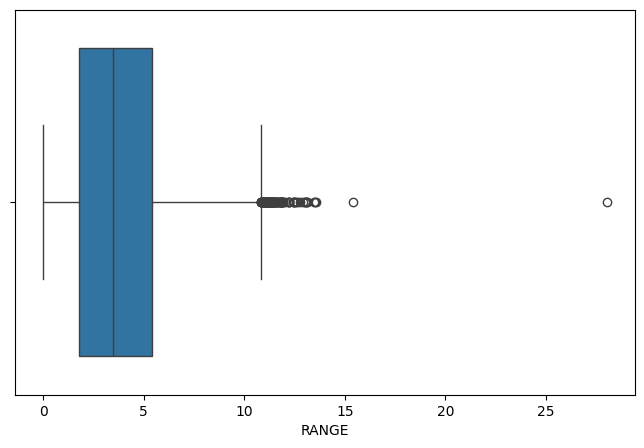

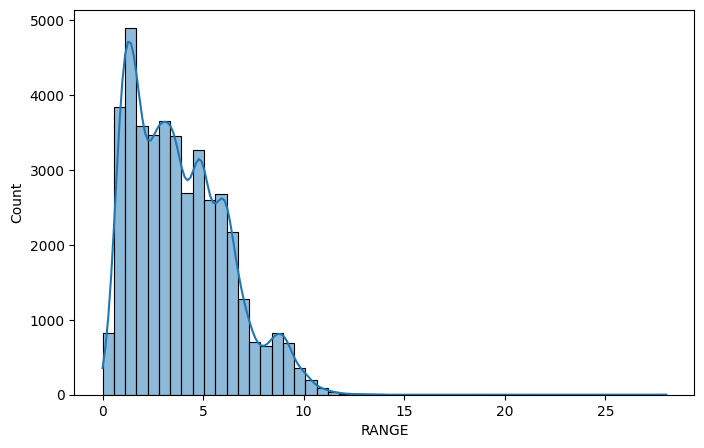

Min: 0.0 Max: 28.02


In [5]:
# Boxplot for RANGE
plt.figure(figsize=(8,5))
sns.boxplot(x=df_cleaned["RANGE"])
plt.show()

# Histogram to check distribution
plt.figure(figsize=(8,5))
sns.histplot(df_cleaned["RANGE"], bins=50, kde=True)
plt.show()

# Check min and max values of RANGE
print("Min:", df_cleaned["RANGE"].min(), "Max:", df_cleaned["RANGE"].max())

In [6]:
Q1 = df_cleaned["RANGE"].quantile(0.25)
Q3 = df_cleaned["RANGE"].quantile(0.75)

# Compute IQR
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers
outliers = df_cleaned[(df_cleaned["RANGE"] < lower_bound) | (df_cleaned["RANGE"] > upper_bound)]
num_outliers = outliers.shape[0]

print("Number of outliers in RANGE:", num_outliers)

Number of outliers in RANGE: 121


#### **Features: FP_IDX, FP_AMP1, FP_AMP2, FP_AMP3**

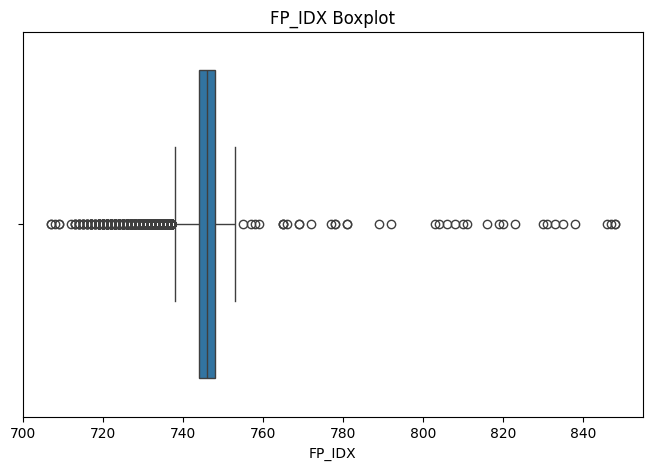

In [7]:
# Plot boxplot for FP_IDX
plt.figure(figsize=(8,5))
sns.boxplot(x=df_cleaned["FP_IDX"])
plt.title("FP_IDX Boxplot")
plt.show()

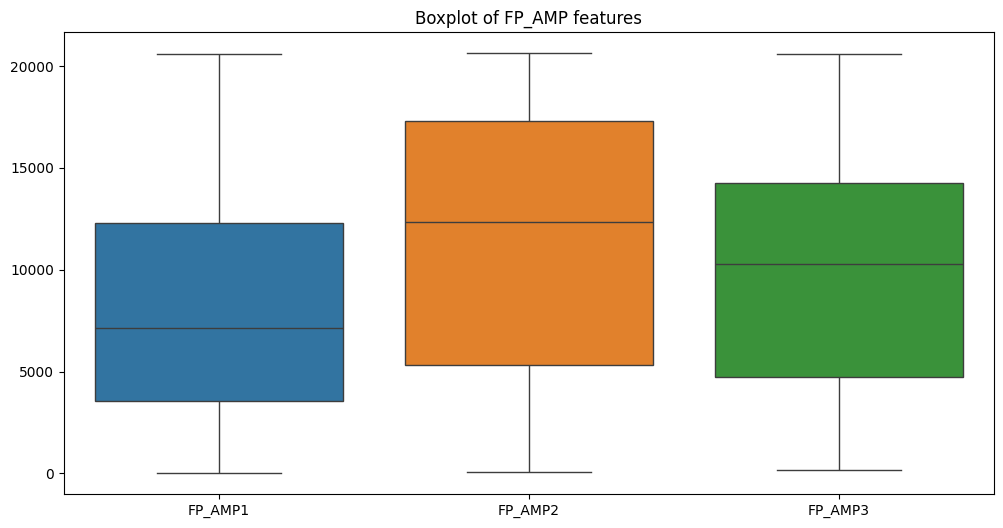

In [8]:
# Plot boxplot for FP_AMP features
# Select features
features = ["FP_AMP1", "FP_AMP2", "FP_AMP3"]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_cleaned[features])
plt.title("Boxplot of FP_AMP features")
plt.show()

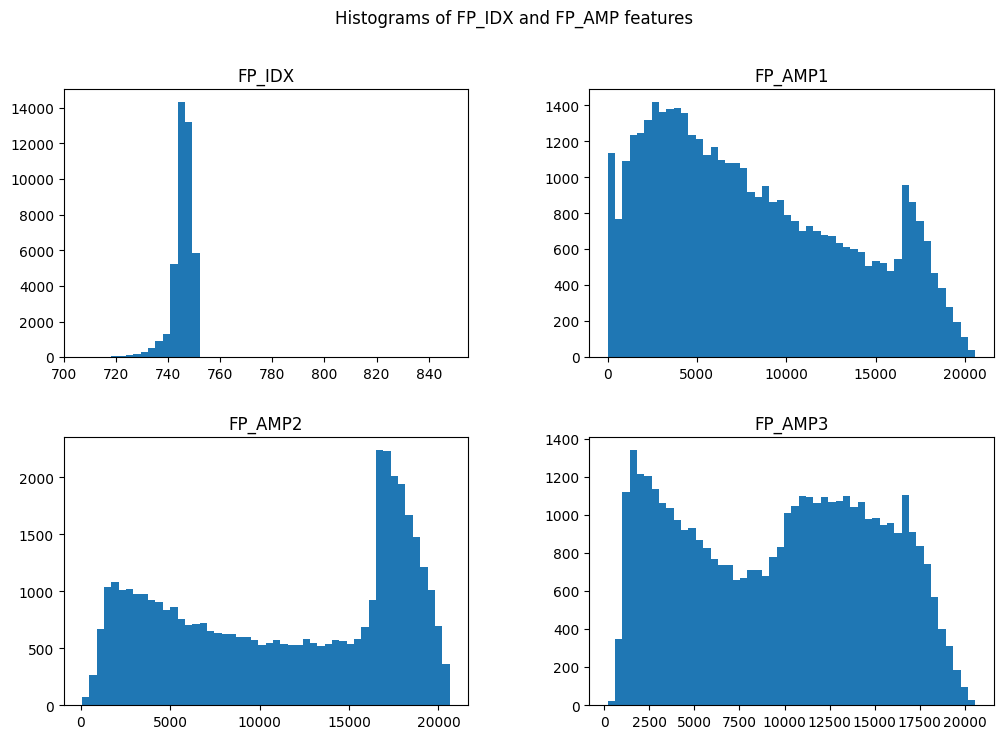

In [9]:
# Plot histogram for FP_IDX and FP_AMP features
# Select features
features = ["FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3"]

df_cleaned[features].hist(bins=50, figsize=(12,8), grid=False)
plt.suptitle("Histograms of FP_IDX and FP_AMP features")
plt.show()

Here, we only remove **extreme outliers** of FP_IDX, FP_AMP1, FP_AMP2, FP_AMP3 that may highly likely be noise, sensor errors, or unusual environmental interfence.

In [10]:
features = ["FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3"]

# Determine Q1 and Q2 of features
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

# Count outliers per feature
outlier_counts = ((df[features] < lower_bound) | (df[features] > upper_bound)).sum()

# Total number of outliers between all features
total_outliers = outlier_counts.sum()

print("Outlier count per feature:")
print(outlier_counts)
print(f"Total outliers across all features: {total_outliers}")

# Mask for outliers
outlier_mask = ((df[features] < lower_bound) | (df[features] > upper_bound)).any(axis=1)

# Remove outliers
df_cleaned = df.loc[outlier_mask != True]

print(f"Dataset shape after removing outliers: {df_cleaned.shape}")

Outlier count per feature:
FP_IDX     622
FP_AMP1      0
FP_AMP2      0
FP_AMP3      0
dtype: int64
Total outliers across all features: 622
Dataset shape after removing outliers: (41378, 1031)


#### **Features: STDEV_NOISE, MAX_NOISE**

For STDEV_NOISE and MAX_NOISE, **extreme outliers** are also removed as these can be likely due to sensor glitches or interference.

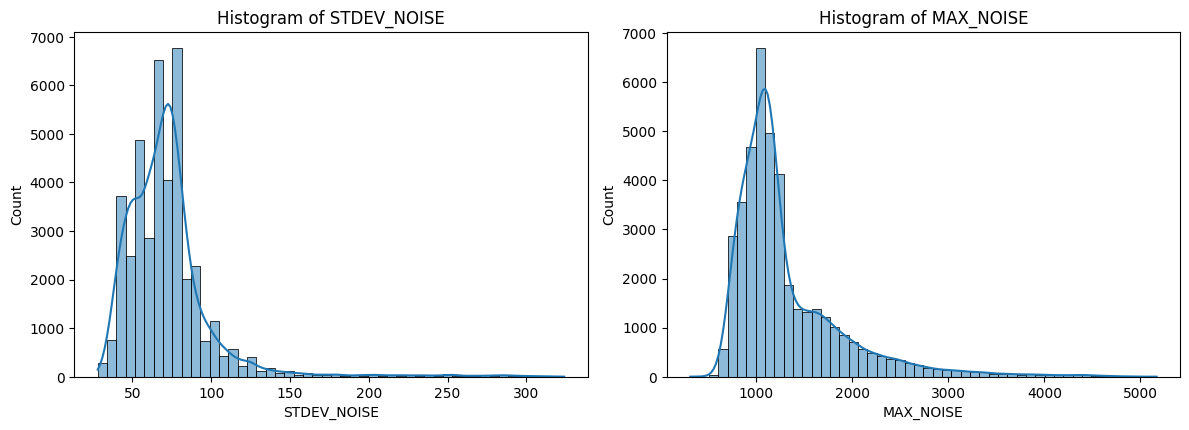

In [11]:
features = ["STDEV_NOISE", "MAX_NOISE"]

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_cleaned[feature], bins=50, kde=True)
    plt.title(f"Histogram of {feature}")

plt.tight_layout()
plt.show()

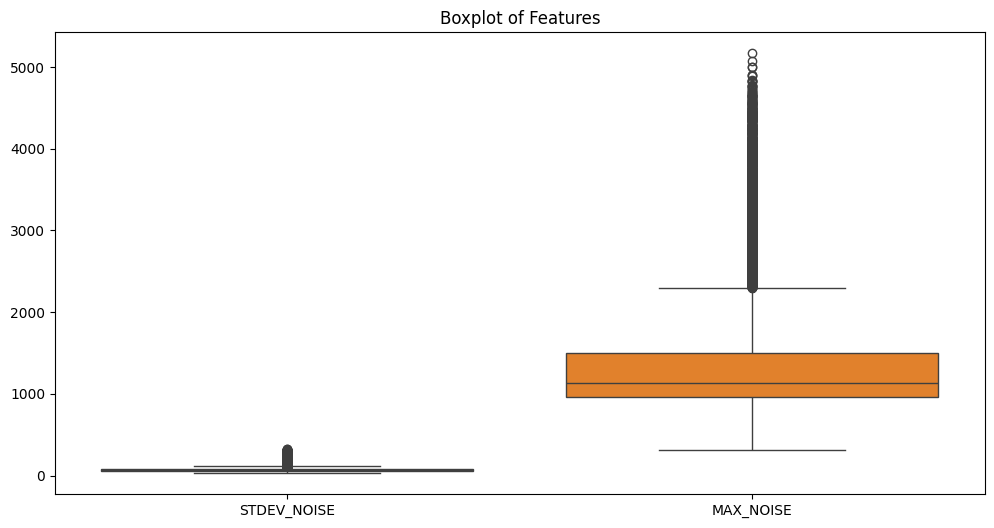

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_cleaned[features])
plt.title("Boxplot of Features")
plt.show()

In [13]:
# Determine Q1 and Q2 of features
Q1 = df_cleaned[features].quantile(0.25)
Q3 = df_cleaned[features].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

# Count outliers per feature
outlier_counts = ((df_cleaned[features] < lower_bound) | (df_cleaned[features] > upper_bound)).sum()

# Total number of outliers between all features
total_outliers = outlier_counts.sum()

print(f'Current dataset shape: {df_cleaned.shape}')
print("Outlier count per feature:")
print(outlier_counts)
print(f"Total outliers across all features: {total_outliers}")

# Mask for outliers
outlier_mask = ((df[features] < lower_bound) | (df[features] > upper_bound)).any(axis=1)

# Remove outliers
df_cleaned = df.loc[outlier_mask != True]

print(f"Dataset shape after removing outliers: {df_cleaned.shape}")

Current dataset shape: (41378, 1031)
Outlier count per feature:
STDEV_NOISE    811
MAX_NOISE      871
dtype: int64
Total outliers across all features: 1682
Dataset shape after removing outliers: (40849, 1031)


#### **Feature: CIR_PWR**

For CIR_PWR, we check for impossible values such as **negative and zero values** as Channel Impulse Response power will never be negative.

In [14]:
print(f'Dataset before cleaning: {df_cleaned.shape}')
impossible_cir_pwr_count = (df_cleaned["CIR_PWR"] <= 0).sum()
print(f"Number of CIR_PWR values ≤ 0: {impossible_cir_pwr_count}")

df_cleaned = df_cleaned[df_cleaned["CIR_PWR"] > 0]
print(f"Dataset shape after removing impossible CIR_PWR values: {df_cleaned.shape}")

Dataset before cleaning: (40849, 1031)
Number of CIR_PWR values ≤ 0: 3
Dataset shape after removing impossible CIR_PWR values: (40846, 1031)


#### **Features: RXPACC, FRAME_LEN, PREAM_LEN, CH, BITRATE, PRFR**

For most of these features, the data should be predefined. Hence, we use a histogram to check for multiple unique values. Besides RXPACC which does not have a predefined value, PREAM_LEN has 2 unique values. 

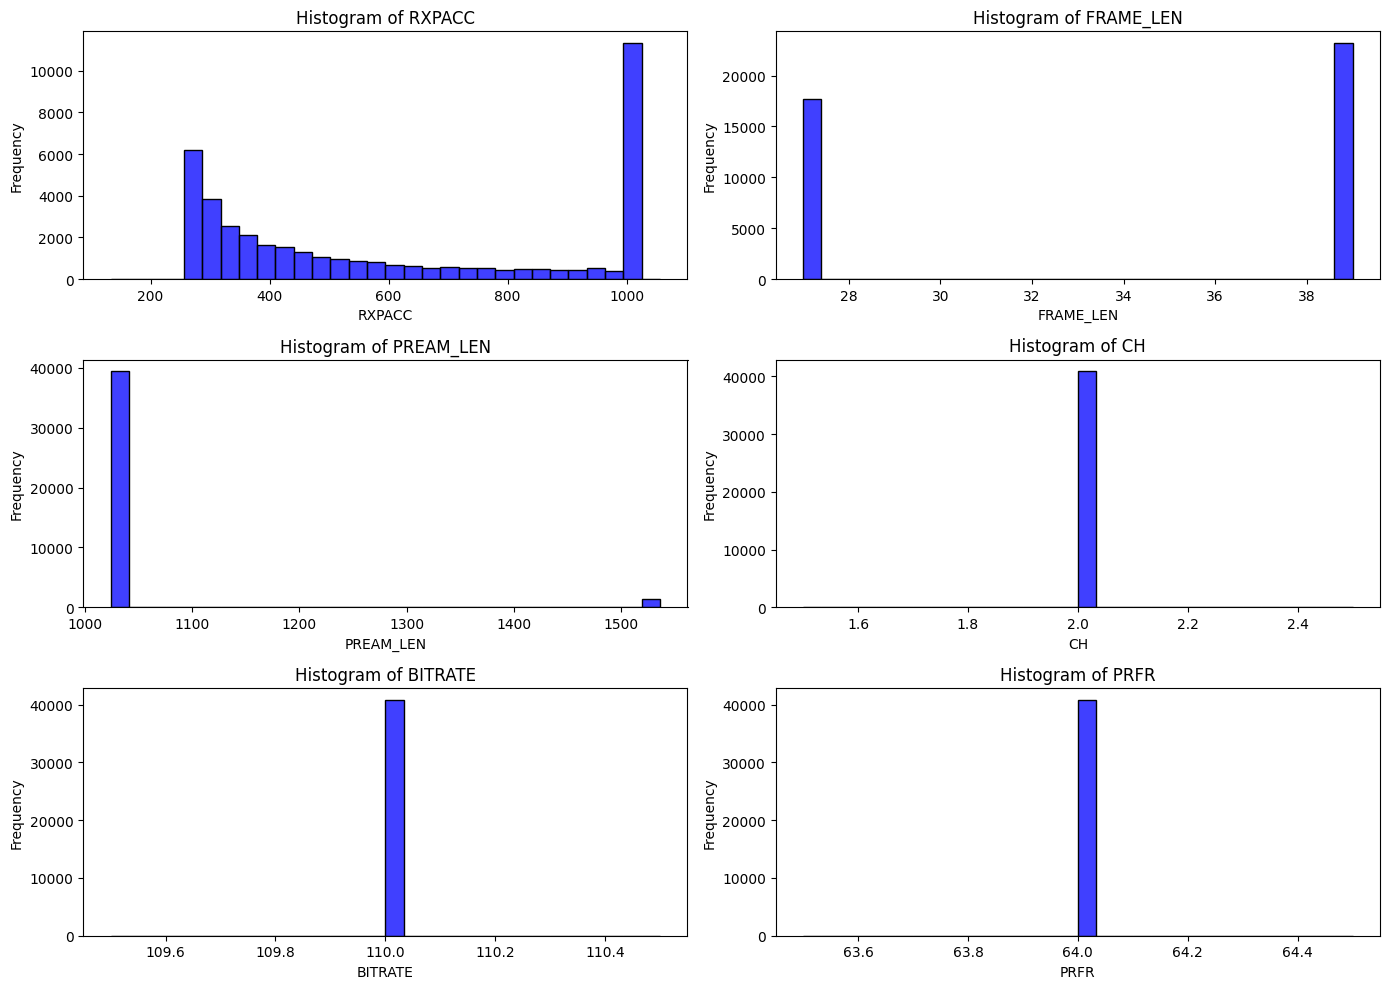

In [15]:
features = ["RXPACC", "FRAME_LEN", "PREAM_LEN", "CH", "BITRATE", "PRFR"]

plt.figure(figsize=(14, 10))

# Loop each feature to plot histogram
for i, feature in enumerate(features, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df_cleaned[feature], bins=30, color="blue")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {feature}")

plt.tight_layout()
plt.show()

To **check for outliers** on RXPACC and PREAM_LEN, we use boxplots to visualize the distribution of data and IQR to count the extreme outliers.

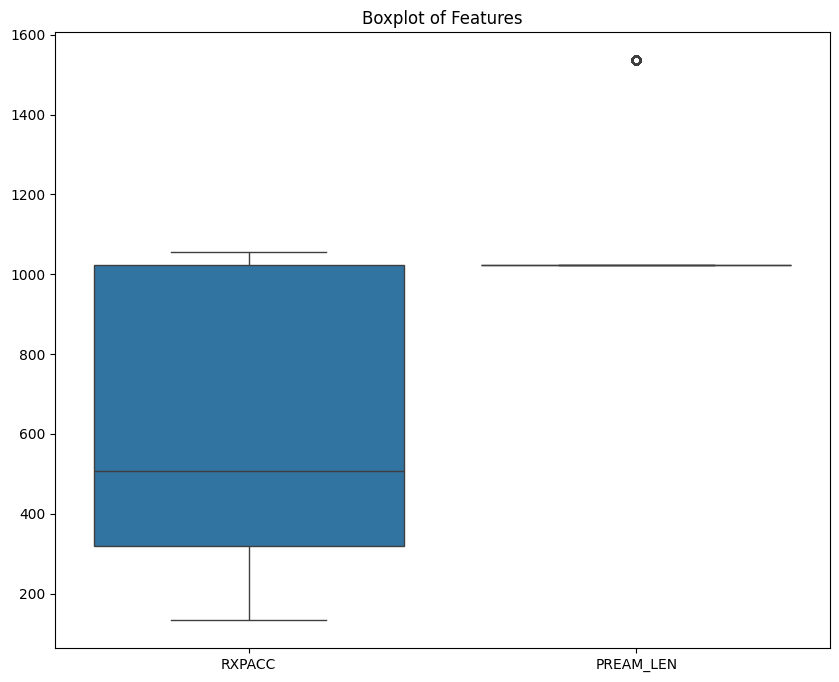

In [16]:
features = ["RXPACC", "PREAM_LEN"]

plt.figure(figsize=(10,8))
sns.boxplot(data=df_cleaned[features])
plt.title("Boxplot of Features")
plt.show()

In [17]:
# Determine Q1 and Q2 of features
Q1 = df_cleaned[features].quantile(0.25)
Q3 = df_cleaned[features].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

# Count outliers per feature
outlier_counts = ((df_cleaned[features] < lower_bound) | (df_cleaned[features] > upper_bound)).sum()

# Total number of outliers between all features
total_outliers = outlier_counts.sum()

print("Outlier count per feature:")
print(outlier_counts)
print(f"Total outliers across all features: {total_outliers}")

Outlier count per feature:
RXPACC          0
PREAM_LEN    1478
dtype: int64
Total outliers across all features: 1478


For futher analysis of PREAM_LEN, we used value_counts(). The output are 2 unique values; 1024.0 and 1536.0. Upon research, 1536 is a valid premeable length so we are **not removing this "outlier"**.

In [18]:
df_cleaned["PREAM_LEN"].value_counts()

PREAM_LEN
1024.0    39368
1536.0     1478
Name: count, dtype: int64

### **Data Visualization and Data Preprocessing**

For features CIR0 to CIR1015 (1016 features), we also did data visualization using heatmap to visualize how the the CIR values behave across multiple data points. After which, we **normalized the CIR values** using RXPACC feature to ensure consistency and reduce bias. Finally, we performed **dimensionality reduction using PCA** to reduce the number of CIR features for effective training of our model. This also removes redundancy and transform highly correlated features into a single feature to improve model performance. 

From the heatmap, we can analyze that the CIR values were **scaled very highly before normalization**, possibly due to noises or differences in signal strength.

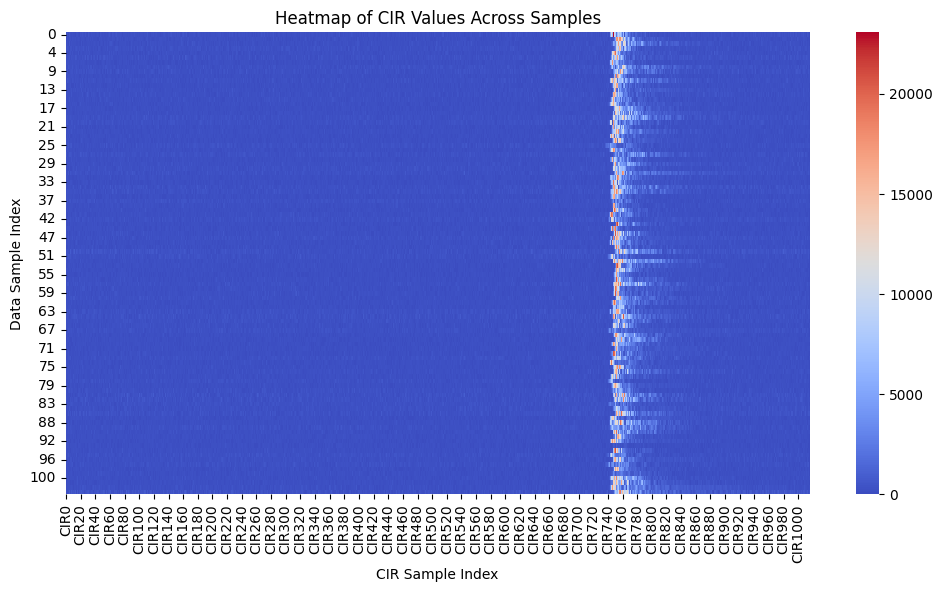

In [19]:
import seaborn as sns

cir_features = [f"CIR{i}" for i in range(1016)]

plt.figure(figsize=(12, 6))
sns.heatmap(df_cleaned[cir_features].iloc[:100], cmap="coolwarm")
plt.xlabel("CIR Sample Index")
plt.ylabel("Data Sample Index")
plt.title("Heatmap of CIR Values Across Samples")
plt.show()

#### **Normalization**

After normalization, we can see CIR values that are more comparable with a smaller scale.

In [20]:
# Function to normalize CIR values using RXPACC
def normalize_cir(df):
    df.iloc[:, 15:] = df.iloc[:, 15:].div(df.iloc[:, 9], axis=0)  # Normalize CIR using RXPACC

# Apply normalization to df_cleaned
normalize_cir(df_cleaned)

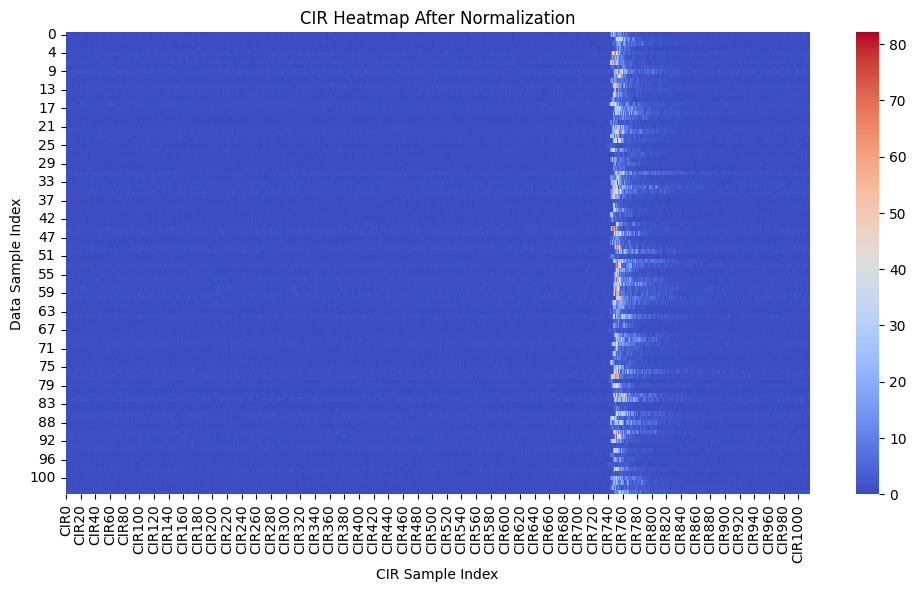

In [21]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_cleaned.iloc[:100, 15:], cmap="coolwarm")
plt.xlabel("CIR Sample Index")
plt.ylabel("Data Sample Index")
plt.title("CIR Heatmap After Normalization")
plt.show()

#### **Principal Component Analysis (PCA)**

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print(f'Shape before PCA: {df_cleaned.shape}')

# Step 1: Extract CIR Features
cir_features = [f"CIR{i}" for i in range(1016)]
X_cir = df_cleaned[cir_features]  
original_features = X_cir.shape[1]  # Number of features in original dataset

# Step 2: Standardize the Data (PCA requires normalization)
scaler = StandardScaler()
X_cir_scaled = scaler.fit_transform(X_cir)

pca = PCA(n_components=0.95)  # Keep 95% variance
X_cir_pca = pca.fit_transform(X_cir_scaled)
reduced_features = X_cir_pca.shape[1]   # Number of features after PCA

# Print PCA results
print(f"New shape of transformed data: {X_cir_pca.shape}")
print(f"Number of features before PCA: {original_features}")
print(f"Number of features after PCA: {reduced_features}")
print(f"Number of features removed: {original_features - reduced_features}")

Shape before PCA: (40846, 1031)
New shape of transformed data: (40846, 842)
Number of features before PCA: 1016
Number of features after PCA: 842
Number of features removed: 174


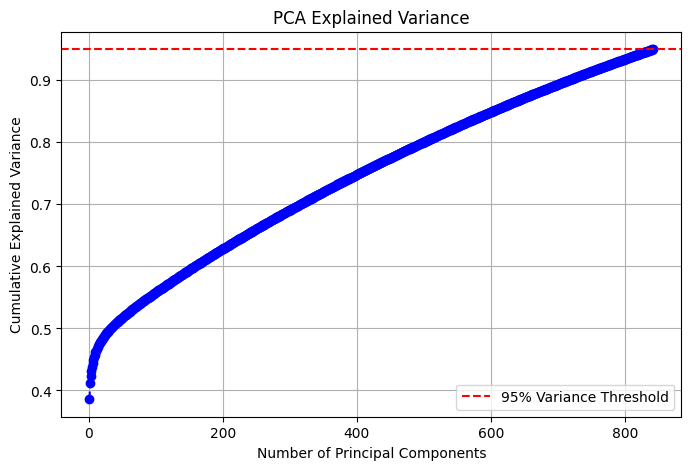

In [23]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True)
plt.show()


### **Feature Importance**

To evaluate the feature importance, we explored various visualization graphs such as correlation matrix and mutual information on all features except CIR features. Ultimately, this is to check which features has the **strongest relationship to our target variable**, 'RANGE', such that we can focus on those features and reduce model complexity by removing/ focusing lesser on less important features.

#### **Correlation Matrix**

Correlation matrix detects if the feature has a positive/ negative linear relationship. However, since it can only check for positive/ negative linear relationship, it may not provide an accurate ranking of each feature's importance to our target variable.

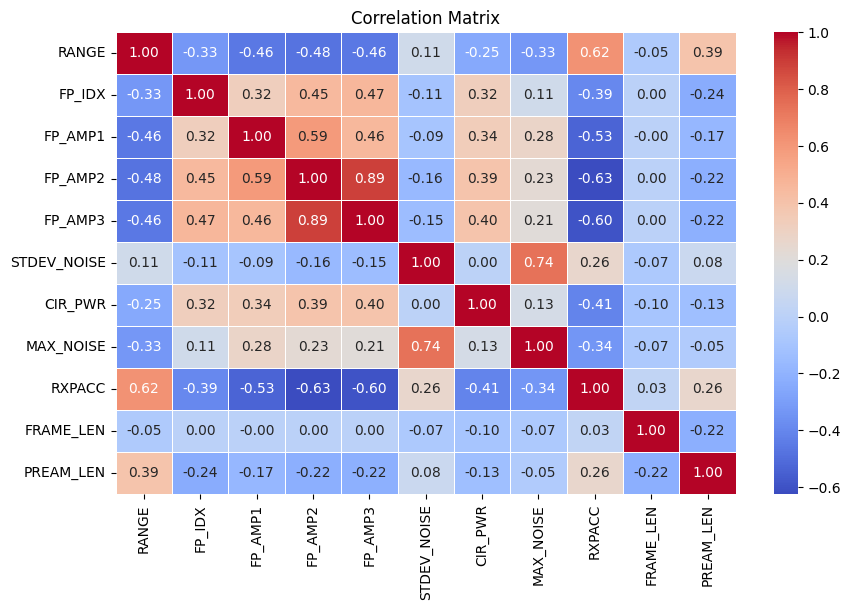

In [24]:
# Shortlisted features to check correlation with each other
features = ['RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
            'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
            'FRAME_LEN','PREAM_LEN']

# Compute the correlation matrix
correlation_matrix = df_cleaned[features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

#### **Mutual Information**

Besides the use of correlation matrix, we used mutual information analysis to further check the relationship of our features with our target variable. Mutual information detects both linear and non-linear relationship and provides a better analysis of which feature contributes to the target variable best. 

Mutual Information Scores (in descending order):
RXPACC         0.380576
MAX_NOISE      0.207161
CIR_PWR        0.176946
FP_AMP2        0.149506
FP_AMP1        0.147740
FP_AMP3        0.136556
STDEV_NOISE    0.090912
FP_IDX         0.083215
PREAM_LEN      0.082741
FRAME_LEN      0.007978
dtype: float64


C:\Users\syahm\AppData\Local\Temp\ipykernel_9352\2907315880.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_scores.index, y=mi_scores.values, palette="viridis")


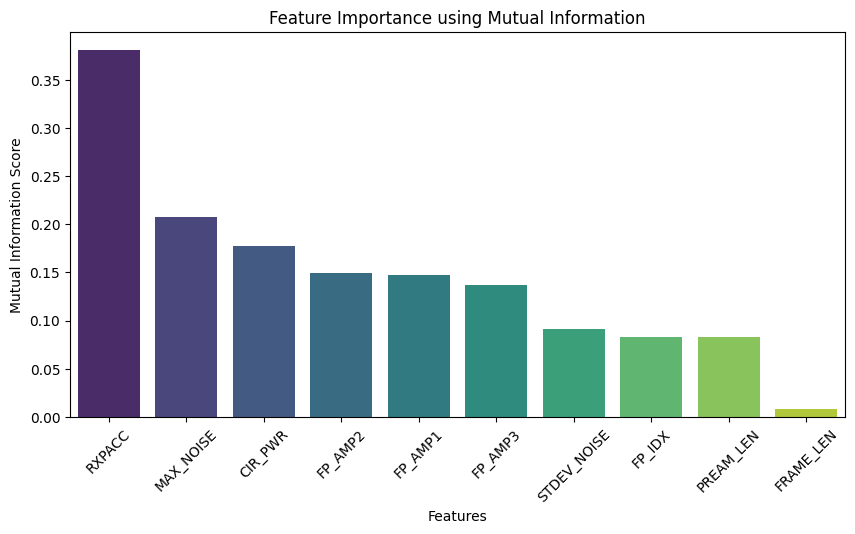

In [25]:
from sklearn.feature_selection import mutual_info_regression

# Features
features = ['FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
            'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
            'FRAME_LEN','PREAM_LEN']

# Define X as features set
X = df_cleaned[features]

# Define target variable
y = df_cleaned["RANGE"]

# Compute mutual information scores
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, index=features)

# Sort the scores in descending order and print
mi_scores = mi_scores.sort_values(ascending=False)
print("Mutual Information Scores (in descending order):")
print(mi_scores)

# Plot the scores for better visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=mi_scores.index, y=mi_scores.values, palette="viridis")
plt.xlabel("Features")
plt.ylabel("Mutual Information Score")
plt.title("Feature Importance using Mutual Information")
plt.xticks(rotation=45)
plt.show()

From the correlation matrix and mutual information results, we can infer that **RXPACC has the strongest relationship with RANGE**. Other **notable features are MAX_NOISE and CIR_PWR** that could possibly provide valuable information when training our model. The **lowest importance features are FRAME_LEN and PREAM_LEN** with 0.007965 and 0.075605 MI scores respectively. Though these features are relatively unimportant, we will kepe these features first to check the model's performance with it. 

## **Data Mining**

### **Checking data**

We check the shape and columns to verify the features we are using for data mining

In [26]:
# Checking dataset original shape 
print(f"Dataset shape before removing features: {df_cleaned.shape}")

# Drop original CIR features
df_cleaned = df_cleaned.drop(columns=cir_features)
print(f"Dataset shape after removing CIR features: {df_cleaned.shape}")

# Load PCA features into a drataframe
df_pca = pd.DataFrame(X_cir_pca, columns=[f"PCA{i+1}" for i in range(reduced_features)])
print(f"Shape of PCA dataset: {df_pca.shape}")

# Add PCA features to the dataframe
df_cleaned = pd.concat([df_cleaned.reset_index(drop=True), df_pca.reset_index(drop=True)], axis=1)

# Print the updated dataframe shape
print()
print(f"Updated dataframe shape: {df_cleaned.shape}")
print(f"Updated dataframe columns: {df_cleaned.columns}")
print(f"NaN values in updated dataframe: {df_cleaned.isnull().sum().sum()}")

Dataset shape before removing features: (40846, 1031)
Dataset shape after removing CIR features: (40846, 15)
Shape of PCA dataset: (40846, 842)

Updated dataframe shape: (40846, 857)
Updated dataframe columns: Index(['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
       'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
       ...
       'PCA833', 'PCA834', 'PCA835', 'PCA836', 'PCA837', 'PCA838', 'PCA839',
       'PCA840', 'PCA841', 'PCA842'],
      dtype='object', length=857)
NaN values in updated dataframe: 0


### **Data Splitting**

#### **80-20 split**

The data was split into 80-20.

In [27]:
from sklearn.model_selection import train_test_split

# Define X and y
X = df_cleaned.drop(columns=["RANGE"])
y = df_cleaned["RANGE"]

# Perform 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print shapes to verify
print("Training feature set shape:", X_train.shape)
print("Testing feature set shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training feature set shape: (32676, 856)
Testing feature set shape: (8170, 856)
Training labels shape: (32676,)
Testing labels shape: (8170,)


#### **Check for NaN values**

Last check for NaN values before training the model. This is done as we faced NaN values when concatinating df_pca into df_cleaned.

In [28]:
# Check if there are any NaN values in X_train or y_train
print("NaN values in X_train:", X_train.isnull().sum().sum())
print("NaN values in y_train:", y_train.isnull().sum())

NaN values in X_train: 0
NaN values in y_train: 0


### **Machine Learning**

The algorithms used for machine learning are RBF SVR, Lasso Regression, Random Forest, and Gradient Boosting. These algorithm was mainly used for its ability to handle high-dimensionality and non-linear data. 

In [29]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#### **RBF SVR**

Our dataset exhibits non-linear relationships, and RBF SVR can effectively capture these patterns by mapping features into a higher-dimensional space, leading to better prediction accuracy compared to linear models.

##### **Baseline SVM Parameters for Regression**

1. **kernel:** `'rbf'` – Standard choice for non-linear regression.  
2. **C:** `1.0` – Default regularization, balancing underfitting and overfitting.  
3. **epsilon:** `0.1` – Standard tolerance; can be tuned for precision.  
4. **gamma:** `'scale'` – Adapts to data size/variance; recommended since scikit-learn 0.22.  


In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Create the SVR model with RBF kernel
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale') 

# 3. Train the model
svr_model.fit(X_train_scaled, y_train)

# 4. Predict on test data
y_pred = svr_model.predict(X_test_scaled)

In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Compute MSE manually
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Manual square root for RMSE
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"SVR RBF Results:\nMSE:{mse:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR² Score: {r2:.4f}")

SVR RBF Results:
MSE:2.3156
RMSE: 1.5217
MAE: 1.1515
R² Score: 0.5739


The SVR model with the RBF kernel provides a decent baseline, explaining 57% of the variance with moderate 
prediction errors (RMSE: 1.52). There is clear potential for optimization

In [32]:
# Predict on training data
y_train_pred = svr_model.predict(X_train_scaled)

# Predict on test data
y_test_pred = svr_model.predict(X_test_scaled)

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Training metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = train_mse ** 0.5
train_r2 = r2_score(y_train, y_train_pred)

# Testing metrics
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = test_mse ** 0.5
test_r2 = r2_score(y_test, y_test_pred)

# Print comparison
print("SVR Model Performance:")
print(f"Training RMSE: {train_rmse:.4f} | Training R²: {train_r2:.4f}")
print(f"Testing  RMSE: {test_rmse:.4f} | Testing  R²: {test_r2:.4f}")


SVR Model Performance:
Training RMSE: 1.2226 | Training R²: 0.7303
Testing  RMSE: 1.5217 | Testing  R²: 0.5739


I trained an SVR model with an RBF kernel and performed hyperparameter tuning. The final model achieved a training R² of 0.73 and a testing R² of 0.57. While there’s a slight gap between training and testing performance, the tuning has provided a solid baseline. Moving forward, I may explore additional techniques like cross-validation or alternative models to further improve the results.

##### **Hyperparameter Tuning: C**

In [33]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Feasible C values
C_values = [0.5, 3, 5]  # Updated C values

for c in C_values:
    print(f"\nTraining SVR model with C={c}")
    
    # Create SVR model
    svr_model = SVR(kernel='rbf', C=c, epsilon=0.1, gamma='scale')
    
    # Train the model
    svr_model.fit(X_train_scaled, y_train)
    
     # Predict on test data
    y_test_pred = svr_model.predict(X_test_scaled)
    
    # Evaluate the model (TEST DATA ONLY)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    
    # Print metrics (Test set)
    print(f"SVR Model Performance with C = {c}:")
    print(f"Test MSE  : {mse:.4f}")
    print(f"Test RMSE : {rmse:.4f}")
    print(f"Test MAE  : {mae:.4f}")
    print(f"Test R²   : {r2:.4f}")
    print("----------------------------------------------------------------------------------------" )



Training SVR model with C=0.5
SVR Model Performance with C = 0.5:
Test MSE  : 2.3768
Test RMSE : 1.5417
Test MAE  : 1.1648
Test R²   : 0.5627
----------------------------------------------------------------------------------------

Training SVR model with C=3
SVR Model Performance with C = 3:
Test MSE  : 2.2563
Test RMSE : 1.5021
Test MAE  : 1.1493
Test R²   : 0.5848
----------------------------------------------------------------------------------------

Training SVR model with C=5
SVR Model Performance with C = 5:
Test MSE  : 2.2430
Test RMSE : 1.4977
Test MAE  : 1.1505
Test R²   : 0.5873
----------------------------------------------------------------------------------------


After evaluating different C values, I observed that increasing C improved the model’s performance, with C = 5 giving the best results. It achieved the lowest test RMSE (1.4337) and the highest R² score (0.6154), indicating better predictive accuracy and variance explanation. Based on these metrics, I have decided to proceed with C = 5 as the optimal regularization parameter for my SVR model.

In [34]:
# Retrain the model at C=5 if needed
svr_model = SVR(kernel='rbf', C=5, epsilon=0.1, gamma='scale')
svr_model.fit(X_train_scaled, y_train)

# Predict on both training and testing data
y_train_pred = svr_model.predict(X_train_scaled)
y_test_pred = svr_model.predict(X_test_scaled)

# Evaluate training performance
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = train_mse ** 0.5
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate testing performance
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = test_mse ** 0.5
test_r2 = r2_score(y_test, y_test_pred)

# Print train vs test performance
print(f"\nSVR Model Performance for C=5 (Train vs Test):")
print(f"Training RMSE: {train_rmse:.4f} | Training R²: {train_r2:.4f}")
print(f"Testing  RMSE: {test_rmse:.4f} | Testing  R²: {test_r2:.4f}")



SVR Model Performance for C=5 (Train vs Test):
Training RMSE: 0.7659 | Training R²: 0.8942
Testing  RMSE: 1.4977 | Testing  R²: 0.5873


After retraining the SVR model with C = 5, I achieved a training RMSE of 0.7439 and R² of 0.8974, showing a strong fit on the training data. On the test set, the RMSE is 1.4337 with an R² of 0.6154, indicating the model generalizes reasonably well. The performance gap between training and testing suggests a slight overfitting, but overall, C = 5 offers a good balance of accuracy and generalization for my current model. Therefore, I’ve chosen C = 5 as the final parameter for this SVR model.

##### **Hyperparameter Tuning: Epsilon**


In [35]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Scale the features (optional if already done)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Fixed C
fixed_C = 5.0

# 3. Feasible epsilon values to try
epsilon_values = [0.01, 0.1, 0.5, 1.0]

# 4. Iterate over epsilon values
for eps in epsilon_values:
    print(f"\nTraining SVR Model with C={fixed_C} and epsilon={eps}")

    # Create the SVR model with fixed C and varying epsilon
    svr_model = SVR(kernel='rbf', C=fixed_C, epsilon=eps, gamma='scale')
    
    # Train the model
    svr_model.fit(X_train_scaled, y_train)
    
    # Predict on test data
    y_test_pred = svr_model.predict(X_test_scaled)
    
    # Evaluate the model (TEST DATA ONLY for hyperparameter tuning)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    
    # Print metrics (Test set)
    print(f"SVR Model Performance with epsilon = {eps}:")
    print(f"Test MSE  : {mse:.4f}")
    print(f"Test RMSE : {rmse:.4f}")
    print(f"Test MAE  : {mae:.4f}")
    print(f"Test R²   : {r2:.4f}")
    print("-" * 60)



Training SVR Model with C=5.0 and epsilon=0.01
SVR Model Performance with epsilon = 0.01:
Test MSE  : 2.2435
Test RMSE : 1.4978
Test MAE  : 1.1484
Test R²   : 0.5872
------------------------------------------------------------

Training SVR Model with C=5.0 and epsilon=0.1
SVR Model Performance with epsilon = 0.1:
Test MSE  : 2.2430
Test RMSE : 1.4977
Test MAE  : 1.1505
Test R²   : 0.5873
------------------------------------------------------------

Training SVR Model with C=5.0 and epsilon=0.5
SVR Model Performance with epsilon = 0.5:
Test MSE  : 2.2563
Test RMSE : 1.5021
Test MAE  : 1.1675
Test R²   : 0.5848
------------------------------------------------------------

Training SVR Model with C=5.0 and epsilon=1.0
SVR Model Performance with epsilon = 1.0:
Test MSE  : 2.3243
Test RMSE : 1.5246
Test MAE  : 1.2082
Test R²   : 0.5723
------------------------------------------------------------


Conclusion :

Lower epsilon values (0.01 and 0.1) resulted in better model accuracy, with minimal differences in performance between them. Although epsilon = 0.01 provided slightly better metrics, it significantly increased training time (around 5 hours) compared to epsilon = 0.1, which completed in approximately 1.5 hours.

Considering the marginal performance gain versus the increased computational cost and higher risk of overfitting with very small epsilon values, I have chosen epsilon = 0.1 as the more practical and balanced option.

At this point, there’s no need to further compare training and testing results, as this choice aligns with the previously selected default and provides a reliable balance between accuracy, efficiency, and generalization.

##### **Hyperparmeter Tuning: Gamma**

In [36]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

# 1. Scale the features (you've already done this but included for clarity)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Fixed values
fixed_C = 5.0
fixed_epsilon = 0.1

# 3. Gamma values to try (excluding 'scale' and 1)
gamma_values = ['auto', 0.01, 0.1]

# 4. Iterate over gamma values
for gamma in gamma_values:
    print(f"\nTraining SVR Model with C={fixed_C}, epsilon={fixed_epsilon}, gamma={gamma}")
    
    start_time = time.time()
    
    # Create and train the SVR model
    svr_model = SVR(kernel='rbf', C=fixed_C, epsilon=fixed_epsilon, gamma=gamma)
    svr_model.fit(X_train_scaled, y_train)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    # Predict on test data
    y_test_pred = svr_model.predict(X_test_scaled)
    
    # Evaluate the model (Test data only)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    
    # Print metrics (Test set)
    print(f"SVR Model Performance with gamma = {gamma}:")
    print(f"Test MSE  : {mse:.4f}")
    print(f"Test RMSE : {rmse:.4f}")
    print(f"Test MAE  : {mae:.4f}")
    print(f"Test R²   : {r2:.4f}")
    print(f"Training Time: {elapsed_time:.2f} seconds")
    print("-" * 60)



Training SVR Model with C=5.0, epsilon=0.1, gamma=auto
SVR Model Performance with gamma = auto:
Test MSE  : 2.2431
Test RMSE : 1.4977
Test MAE  : 1.1505
Test R²   : 0.5873
Training Time: 1523.93 seconds
------------------------------------------------------------

Training SVR Model with C=5.0, epsilon=0.1, gamma=0.01
SVR Model Performance with gamma = 0.01:
Test MSE  : 3.4112
Test RMSE : 1.8470
Test MAE  : 1.5076
Test R²   : 0.3723
Training Time: 1486.98 seconds
------------------------------------------------------------

Training SVR Model with C=5.0, epsilon=0.1, gamma=0.1
SVR Model Performance with gamma = 0.1:
Test MSE  : 5.4356
Test RMSE : 2.3314
Test MAE  : 1.9101
Test R²   : -0.0001
Training Time: 1499.72 seconds
------------------------------------------------------------


After experimenting with different gamma values (auto, 0.01, and 0.1), I found that the original gamma setting (scale) provided the best overall performance. With C = 5.0 and epsilon = 0.1, using gamma='scale' resulted in a test RMSE of 1.4337 and an R² score of 0.6154, outperforming the other gamma values tested.

The alternative gamma values led to higher errors and lower R² scores, without any meaningful improvement in training time. Therefore, I decided to keep gamma='scale' as the final choice, as it offers the best balance between accuracy, generalization, and efficiency for this SVR model.

##### **Hyperparameter Tuning: C**

Since increasing the C value tends to improve model accuracy by allowing the SVR to fit the data more closely, we proceeded to experiment with higher C values to explore potential gains in predictive performance.

In [37]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import time

# 1. Scale the features (already done previously)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Feasible C values to tune (updated)
C_values = [7, 10]  # New C values for hyperparameter tuning

# 3. Fixed epsilon and gamma
fixed_epsilon = 0.1
fixed_gamma = 'scale'

# 4. Iterate over C values
for c in C_values:
    print(f"\nTraining SVR model with C={c}, epsilon={fixed_epsilon}, gamma={fixed_gamma}")
    
    start_time = time.time()
    
    # Create the SVR model
    svr_model = SVR(kernel='rbf', C=c, epsilon=fixed_epsilon, gamma=fixed_gamma)
    
    # Train the model
    svr_model.fit(X_train_scaled, y_train)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    # Predict on test data
    y_test_pred = svr_model.predict(X_test_scaled)
    
    # Evaluate the model (TEST DATA ONLY)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    
    # Print performance metrics
    print(f"SVR Model Performance with C = {c}:")
    print(f"Test MSE  : {mse:.4f}")
    print(f"Test RMSE : {rmse:.4f}")
    print(f"Test MAE  : {mae:.4f}")
    print(f"Test R²   : {r2:.4f}")
    print(f"Training Time: {elapsed_time:.2f} seconds")
    print("-" * 80)


Training SVR model with C=7, epsilon=0.1, gamma=scale
SVR Model Performance with C = 7:
Test MSE  : 2.2403
Test RMSE : 1.4968
Test MAE  : 1.1520
Test R²   : 0.5878
Training Time: 1715.53 seconds
--------------------------------------------------------------------------------

Training SVR model with C=10, epsilon=0.1, gamma=scale
SVR Model Performance with C = 10:
Test MSE  : 2.2442
Test RMSE : 1.4981
Test MAE  : 1.1549
Test R²   : 0.5871
Training Time: 1956.37 seconds
--------------------------------------------------------------------------------


##### **Conclusion and Save Model**
Increasing C to 7 and 10 (with epsilon = 0.1 and gamma = 'scale') did not improve performance. Instead, test metrics worsened slightly: C = 7 gave RMSE = 1.4968, R² = 0.5878, while C = 10 resulted in RMSE = 1.4981, R² = 0.5871. Training time also increased significantly, with C = 10 taking over 1.5 hours.

Since higher C values add complexity without improving accuracy, I am keeping C = 5, epsilon = 0.1, and gamma = 'scale' for the best balance of accuracy, generalization, and efficiency.

In [38]:
import joblib

svr_model = SVR(kernel='rbf', C=5, epsilon=0.1, gamma='scale')
svr_model.fit(X_train_scaled, y_train)

# Define the directory
models_path = "models"
os.makedirs(models_path, exist_ok=True)

# Save the SVR model
model_filename = os.path.join(models_path, "rbfSVR.pkl")
joblib.dump(svr_model, model_filename)

print(f"Saved SVR model at: {model_filename}")

Saved SVR model at: models\rbfSVR.pkl


#### **Lasso Regression**

Lasso Regression was used for its ability to handle high-dimensionality datasets, helps with feature selection by applying L1 regularization, and reducing overfitting.

##### **Hyperparameter Tuning: Alpha**

Alpha is the regularization strength to control the balance between fitting the model to the data and penalizing large coefficients.

In [39]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

def train_basic_lasso(X_train, y_train, X_test, y_test, alpha):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, max_iter=10000, random_state=42))
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    # Calculate MSE and RMSE
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    
    # Calculate R² scores
    test_r2 = r2_score(y_test, y_pred_test)
    
    # Extract Lasso coefficients
    lasso_model = pipeline.named_steps['lasso']
    coef = lasso_model.coef_
    features_selected = np.sum(coef != 0)
    
    # Evaluation metrics
    print(f"Model evaluation metrics for Lasso Regression with {alpha} alphas")
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Test R²: {test_r2:.4f}")
    print(f"Number of features selected: {features_selected} out of {len(coef)}\n")
    
    return pipeline, coef

# Tuning
alphas = [0.1, 0.01, 0.001, 0.0001]
for alpha in alphas:
    print(f"Training Lasso model with alpha={alpha}")
    basic_model, basic_coef = train_basic_lasso(X_train, y_train, X_test, y_test, alpha)

Training Lasso model with alpha=0.1
Model evaluation metrics for Lasso Regression with 0.1 alphas
Train MSE: 2.6217
Test MSE: 2.6882
Train RMSE: 1.6192
Test RMSE: 1.6396
Test R²: 0.5054
Number of features selected: 12 out of 856

Training Lasso model with alpha=0.01
Model evaluation metrics for Lasso Regression with 0.01 alphas
Train MSE: 2.3724
Test MSE: 2.4831
Train RMSE: 1.5402
Test RMSE: 1.5758
Test R²: 0.5431
Number of features selected: 350 out of 856

Training Lasso model with alpha=0.001
Model evaluation metrics for Lasso Regression with 0.001 alphas
Train MSE: 2.3004
Test MSE: 2.4704
Train RMSE: 1.5167
Test RMSE: 1.5717
Test R²: 0.5455
Number of features selected: 814 out of 856

Training Lasso model with alpha=0.0001
Model evaluation metrics for Lasso Regression with 0.0001 alphas
Train MSE: 2.2986
Test MSE: 2.4753
Train RMSE: 1.5161
Test RMSE: 1.5733
Test R²: 0.5446
Number of features selected: 849 out of 856



##### **Hyperparameter Tuning: No. of maximum iterations**

The number of maximum iterations determines how many optimizations steps Lasso Regression will take before stopping. 

In [40]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

def train_basic_lasso(X_train, y_train, X_test, y_test, iteration):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=0.01, max_iter=iteration, random_state=42))
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    # Calculate MSE and RMSE
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    
    # Calculate R² scores
    test_r2 = r2_score(y_test, y_pred_test)
    
    # Extract Lasso coefficients
    lasso_model = pipeline.named_steps['lasso']
    coef = lasso_model.coef_
    features_selected = np.sum(coef != 0)
    
    # Evaluation metrics
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Test R²: {test_r2:.4f}")
    print(f"Number of features selected: {features_selected} out of {len(coef)}\n")
    
    return pipeline, coef

# Tuning
iterations = [5000, 10000, 20000, 30000]
for iteration in iterations:
    print(f"Training Lasso model with interations={iteration}")
    basic_model, basic_coef = train_basic_lasso(X_train, y_train, X_test, y_test, iteration)

Training Lasso model with interations=5000
Train MSE: 2.3724
Test MSE: 2.4831
Train RMSE: 1.5402
Test RMSE: 1.5758
Test R²: 0.5431
Number of features selected: 350 out of 856

Training Lasso model with interations=10000
Train MSE: 2.3724
Test MSE: 2.4831
Train RMSE: 1.5402
Test RMSE: 1.5758
Test R²: 0.5431
Number of features selected: 350 out of 856

Training Lasso model with interations=20000
Train MSE: 2.3724
Test MSE: 2.4831
Train RMSE: 1.5402
Test RMSE: 1.5758
Test R²: 0.5431
Number of features selected: 350 out of 856

Training Lasso model with interations=30000
Train MSE: 2.3724
Test MSE: 2.4831
Train RMSE: 1.5402
Test RMSE: 1.5758
Test R²: 0.5431
Number of features selected: 350 out of 856



##### **Conclusion and Save Model**

Hyperparamater tuning the alpha improved model performance by balancing regularization and accuracy. However, tuning the maximum iterations had no effect as the model has already converged effectively after tuning the alpha.

In [41]:
import joblib

def train_basic_lasso(X_train, y_train, X_test, y_test, alpha):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, max_iter=10000, random_state=42))
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_test_pred = pipeline.predict(X_test)
    
    return pipeline

# Shortlisted parameters
alphas = [0.01, 0.001]

# Path to save the model
models_path = 'models'
os.makedirs(models_path, exist_ok=True)

for alpha in alphas:
    model = train_basic_lasso(X_train, y_train, X_test, y_test, alpha)

    # File name and save
    model_filename = os.path.join(models_path, f'lasso_{alpha}_model.pkl')
    joblib.dump(model, model_filename)
    print(f"Model saved: {model_filename}")

Model saved: models\lasso_0.01_model.pkl
Model saved: models\lasso_0.001_model.pkl


#### **Random Forest Regression**

Random Forest Regression was used for its ability to handle high-dimension and non-linear data. Compared to Decision Trees, it further reduces overfitting by averaging predictions on multiple trees. It's also robust to outliers, allowing us to keep mild outliers that may contribute to the prediction of RANGE. 

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,  
    max_depth=None,    
    min_samples_split=2, 
    min_samples_leaf=1,  
    random_state=42,      
    n_jobs=-1              
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Calculate training metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

# Calculate testing metrics
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
r2 = r2_score(y_test, y_test_pred)

# Print evaluation metrics
print("Model Performance Metrics of Random Forest Regression:")
print(f"Training MSE: {train_mse:.4f}")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing RMSE: {test_rmse:.4f}")
print(f"Testing R² Score: {r2:.4f}")

Model Performance Metrics of Random Forest Regression:
Training MSE: 0.2363
Testing MSE: 1.7461
Training RMSE: 0.4862
Testing RMSE: 1.3214
Testing R² Score: 0.6787


##### **Hyperparameter Tuning: Depth**

Depth controls the model complexity, allowing it to capture more/less data patterns depending on the value.

In [43]:
depths = [5, 10, 50]

for depth in depths:
    rf_model = RandomForestRegressor(
        n_estimators=100,  
        max_depth=depth,        
        min_samples_split=2, 
        min_samples_leaf=1,  
        random_state=42,  
        n_jobs=-1
    )

    # Train the model
    rf_model.fit(X_train, y_train)

    # Predict on training and testing sets
    y_train_pred = rf_model.predict(X_train)
    y_test_pred = rf_model.predict(X_test)

    # Compute MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Calculate R² score
    r2 = r2_score(y_test, y_test_pred)

    # Calculate RMSE
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    print(f"Model Performance Metrics for {depth} depths:")
    print(f"Training MSE: {train_mse:.4f}")
    print(f"Testing MSE: {test_mse:.4f}")
    print(f"Training RMSE: {train_rmse:.4f}")
    print(f"Testing RMSE: {test_rmse:.4f}")
    print(f"R² Score: {r2:.4f}")
    print()

Model Performance Metrics for 5 depths:
Training MSE: 2.2639
Testing MSE: 2.3694
Training RMSE: 1.5046
Testing RMSE: 1.5393
R² Score: 0.5640

Model Performance Metrics for 10 depths:
Training MSE: 1.1872
Testing MSE: 1.7815
Training RMSE: 1.0896
Testing RMSE: 1.3347
R² Score: 0.6722

Model Performance Metrics for 50 depths:
Training MSE: 0.2363
Testing MSE: 1.7461
Training RMSE: 0.4862
Testing RMSE: 1.3214
R² Score: 0.6787



##### **Hyperparameter Tuning: Minimum Sample Split**

Minimum Sample Split controls the minimum number of samples required to split an internal node. Tuning the minimum sample splits prevents the model from learning overly specific patterns that can lead to overfitting.

In [44]:
splits = [10, 30, 50]

for split in splits:
    rf_model = RandomForestRegressor(
        n_estimators=100,  
        max_depth=10,        
        min_samples_split=split, 
        min_samples_leaf=1,  
        random_state=42,  
        n_jobs=-1
    )

    # Train the model
    print(f"Training model with {split} sample splits:")
    rf_model.fit(X_train, y_train)

    # Predict on training and testing sets
    y_train_pred = rf_model.predict(X_train)
    y_test_pred = rf_model.predict(X_test)

    # Compute MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Calculate R² score
    r2 = r2_score(y_test, y_test_pred)

    # Calculate RMSE
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    print(f"Model Performance Metrics for {split} sample splits:")
    print(f"Training MSE: {train_mse:.4f}")
    print(f"Testing MSE: {test_mse:.4f}")
    print(f"Training RMSE: {train_rmse:.4f}")
    print(f"Testing RMSE: {test_rmse:.4f}")
    print(f"R² Score: {r2:.4f}")
    print()

Training model with 10 sample splits:
Model Performance Metrics for 10 sample splits:
Training MSE: 1.2034
Testing MSE: 1.7804
Training RMSE: 1.0970
Testing RMSE: 1.3343
R² Score: 0.6724

Training model with 30 sample splits:
Model Performance Metrics for 30 sample splits:
Training MSE: 1.2622
Testing MSE: 1.7803
Training RMSE: 1.1235
Testing RMSE: 1.3343
R² Score: 0.6724

Training model with 50 sample splits:
Model Performance Metrics for 50 sample splits:
Training MSE: 1.3107
Testing MSE: 1.7855
Training RMSE: 1.1449
Testing RMSE: 1.3362
R² Score: 0.6715



##### **Hyperparameter Tuning: Minimum Sample Leaf**

Minimum Sample Leaf controls the number of samples required to be at a leaf node. By tuning this, the model is more generalized as the leaf contains more sample.

In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

leafs = [20, 50, 100]

for leaf in leafs:
    rf_model = RandomForestRegressor(
        n_estimators=100,  
        max_depth=10,        
        min_samples_split=50,  
        min_samples_leaf=leaf,  
        random_state=42,  
        n_jobs=-1
    )

    # Train the model
    rf_model.fit(X_train, y_train)

    # Predict on training and testing sets
    y_train_pred = rf_model.predict(X_train)
    y_test_pred = rf_model.predict(X_test)

    # Compute MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Calculate RMSE
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    # Calculate R² score
    r2 = r2_score(y_test, y_test_pred)

    print(f"Model Performance Metrics for {leaf} leafs:")
    print(f"Training MSE: {train_mse:.4f}")
    print(f"Testing MSE: {test_mse:.4f}")
    print(f"Training RMSE: {train_rmse:.4f}")
    print(f"Testing RMSE: {test_rmse:.4f}")
    print(f"R² Score: {r2:.4f}")
    print()

Model Performance Metrics for 20 leafs:
Training MSE: 1.3470
Testing MSE: 1.7851
Training RMSE: 1.1606
Testing RMSE: 1.3361
R² Score: 0.6716

Model Performance Metrics for 50 leafs:
Training MSE: 1.4969
Testing MSE: 1.8237
Training RMSE: 1.2235
Testing RMSE: 1.3504
R² Score: 0.6644

Model Performance Metrics for 100 leafs:
Training MSE: 1.6750
Testing MSE: 1.8944
Training RMSE: 1.2942
Testing RMSE: 1.3764
R² Score: 0.6514



##### **Hyperparameter Tuning: No. of Estimators**

The number of estimators controls the number of individual trees the algorithm will build. Tuning this allows the model to learn from more data points, leading to higher accuracy.

In [46]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define different n_estimators values
estimators = [100, 300, 500, 600]

# Dictionary to store model performance
model_performance = {}

for estimator in estimators:
    rf_model = RandomForestRegressor(
        n_estimators=estimator,  
        max_depth=10,     
        min_samples_split=50,  
        min_samples_leaf=100,  
        random_state=42,      
        n_jobs=-1          
    )

    # Train the model
    rf_model.fit(X_train, y_train)

    # Predictions on train and test sets
    y_train_pred = rf_model.predict(X_train)
    y_test_pred = rf_model.predict(X_test)

    # Compute train and test MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    # Compute RMSE, MAE, and R²
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Store model performance
    mse_difference = abs(test_mse - train_mse)
    model_performance[estimator] = {
        "model": rf_model,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "mse_difference": mse_difference,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_r2": test_r2
    }

    # Print evaluation metrics
    print(f"Model Performance Metrics for {estimator} Estimators:")
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Test MAE: {test_mae:.4f}")
    print(f"Test R² Score: {test_r2:.4f}")
    print(f"MSE Difference (Test - Train): {mse_difference:.4f}")
    print()

Model Performance Metrics for 100 Estimators:
Train MSE: 1.6750
Test MSE: 1.8944
Test RMSE: 1.3764
Test MAE: 1.0524
Test R² Score: 0.6514
MSE Difference (Test - Train): 0.2195

Model Performance Metrics for 300 Estimators:
Train MSE: 1.6736
Test MSE: 1.8956
Test RMSE: 1.3768
Test MAE: 1.0525
Test R² Score: 0.6512
MSE Difference (Test - Train): 0.2221

Model Performance Metrics for 500 Estimators:
Train MSE: 1.6725
Test MSE: 1.8930
Test RMSE: 1.3759
Test MAE: 1.0520
Test R² Score: 0.6517
MSE Difference (Test - Train): 0.2205

Model Performance Metrics for 600 Estimators:
Train MSE: 1.6731
Test MSE: 1.8935
Test RMSE: 1.3761
Test MAE: 1.0522
Test R² Score: 0.6516
MSE Difference (Test - Train): 0.2204



##### **Conclusion and Save Model**

Hyperparameter tuning allowed us to determine the 2 top performing Random Forest Regression models
1. Estimator = 100, Leaf = 100, Splits = 50, Depth = 10
2. Estimator = 600, Leaf = 100, Splits = 50, Depth = 10

Both the models will be analysed further in data analysis to weigh the pros and cons of each model

In [47]:
import joblib

# Sort models based on smallest MSE difference
sorted_models = sorted(model_performance.items(), key=lambda x: x[1]["mse_difference"])[:2]

# Save top 2 models in directory
for i, (estimator, data) in enumerate(sorted_models):
    models_path = 'models'
    model_filename = os.path.join(models_path, f'randomForest_{estimator}_model.pkl')
    joblib.dump(data["model"], model_filename)
    print(f"Saved: {model_filename} | Estimators: {estimator} | MSE Difference: {data['mse_difference']:.4f}")

Saved: models\randomForest_100_model.pkl | Estimators: 100 | MSE Difference: 0.2195
Saved: models\randomForest_600_model.pkl | Estimators: 600 | MSE Difference: 0.2204


#### **Gradient Boosting Regression**

Gradient Boosting Regression was used for its ability to handle complex data patterns especially when the feature-target relationship is non-linear. By being robust to outliers, it is able to perform better with less overfitting as well as improved accuracy.

##### **Hyperparameter Tuning: No. of Estimators**

In [48]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

model_performances = []
estimators = [50, 100, 300, 400]

for estimator in estimators:
    # Create Gradient Boosting model
    gb_model = GradientBoostingRegressor(n_estimators=estimator, learning_rate=0.1, max_depth=3)

    # Train the model
    gb_model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred_train = gb_model.predict(X_train)
    y_pred_test = gb_model.predict(X_test)

    # Evaluate the model performance on the train set
    train_mse = mean_squared_error(y_train, y_pred_train)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, y_pred_train)

    # Evaluate the model performance on the test set
    test_mse = mean_squared_error(y_test, y_pred_test)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, y_pred_test)

    # For later comparison
    mse_diff = abs(test_mse - train_mse)
    model_performances.append({
        "model": gb_model,
        "description": f"n_estimators={estimator}, learning_rate=0.1, max_depth=3",
        "train_mse": train_mse,
        "test_mse": test_mse,
        "mse_diff": mse_diff
    })

    # Print the evaluation metrics
    print(f"Model Performance Metrics for {estimator} Estimators:")
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²: {test_r2:.4f}")

Model Performance Metrics for 50 Estimators:
Train MSE: 1.9174
Test MSE: 2.0313
Train RMSE: 1.3847
Test RMSE: 1.4252
Train R²: 0.6541
Test R²: 0.6262
Model Performance Metrics for 100 Estimators:
Train MSE: 1.7337
Test MSE: 1.8999
Train RMSE: 1.3167
Test RMSE: 1.3784
Train R²: 0.6872
Test R²: 0.6504
Model Performance Metrics for 300 Estimators:
Train MSE: 1.4737
Test MSE: 1.7869
Train RMSE: 1.2140
Test RMSE: 1.3367
Train R²: 0.7341
Test R²: 0.6712
Model Performance Metrics for 400 Estimators:
Train MSE: 1.4001
Test MSE: 1.7789
Train RMSE: 1.1833
Test RMSE: 1.3338
Train R²: 0.7474
Test R²: 0.6727


##### **Hyperparameter Tuning: Learning Rate**

Learning rate controls how much each new tree should correct the previous model's errors. 

In [49]:
rates = [0.05, 0.01]

for rate in rates:
    # Create Gradient Boosting model
    gb_model = GradientBoostingRegressor(n_estimators=300, learning_rate=rate, max_depth=3)

    # Train the model
    gb_model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred_train = gb_model.predict(X_train)
    y_pred_test = gb_model.predict(X_test)

    # Evaluate the model performance on the train set
    train_mse = mean_squared_error(y_train, y_pred_train)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, y_pred_train)

    # Evaluate the model performance on the test set
    test_mse = mean_squared_error(y_test, y_pred_test)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, y_pred_test)

    mse_diff = abs(test_mse - train_mse)
    model_performances.append({
        "model": gb_model,
        "description": f"n_estimators=300, learning_rate={rate}, max_depth=3",
        "train_mse": train_mse,
        "test_mse": test_mse,
        "mse_diff": mse_diff
    })

    # Print the evaluation metricss
    print(f"Model Performance Metrics for {rate} learning rate:")
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²: {test_r2:.4f}")

Model Performance Metrics for 0.05 learning rate:
Train MSE: 1.6375
Test MSE: 1.8391
Train RMSE: 1.2797
Test RMSE: 1.3561
Train R²: 0.7046
Test R²: 0.6616
Model Performance Metrics for 0.01 learning rate:
Train MSE: 2.1169
Test MSE: 2.2070
Train RMSE: 1.4550
Test RMSE: 1.4856
Train R²: 0.6181
Test R²: 0.5939


##### **Hyperparameter Tuning: Maximum Depth**

In [50]:
depths = [5]

for depth in depths:
    # Create Gradient Boosting model
    gb_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=depth)

    # Train the model
    gb_model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred_train = gb_model.predict(X_train)
    y_pred_test = gb_model.predict(X_test)

    # Evaluate the model performance on the train set
    train_mse = mean_squared_error(y_train, y_pred_train)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, y_pred_train)

    # Evaluate the model performance on the test set
    test_mse = mean_squared_error(y_test, y_pred_test)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, y_pred_test)

    mse_diff = abs(test_mse - train_mse)
    model_performances.append({
        "model": gb_model,
        "description": f"n_estimators=300, learning_rate=0.05, max_depth={depth}",
        "train_mse": train_mse,
        "test_mse": test_mse,
        "mse_diff": mse_diff
    })

    # Print the evaluation metricss
    print(f"Model Performance Metrics for {depth} depth:")
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²: {test_r2:.4f}")

Model Performance Metrics for 5 depth:
Train MSE: 1.1377
Test MSE: 1.6914
Train RMSE: 1.0666
Test RMSE: 1.3005
Train R²: 0.7947
Test R²: 0.6888


##### **Conclusion and Save Models**

After manual verification of the results from tuning Gradient Boosting, we have concluded that the best model parameters are 300 estimators, 0.05 learning rate and maximum depth of 3. It makes smaller errors in prediction as well as explains more variance in the data. 

In [51]:
target_mse = 1.8390
tolerance = 1e-4

# Find the closest model based on test_mse
top_models = [model for model in model_performances if abs(model["test_mse"] - target_mse) < tolerance]

if not top_models:
    print("No models found with test_mse close to target.")
else:
    models_path = 'models'
    os.makedirs(models_path, exist_ok=True)

    # Save top models
    for i, model_data in enumerate(top_models):
        model_filename = os.path.join(models_path, f'gradientBoosting_model{i+1}.pkl')
        joblib.dump(model_data["model"], model_filename)
        print(f"Saved {model_filename} - {model_data['description']}")


Saved models\gradientBoosting_model1.pkl - n_estimators=300, learning_rate=0.05, max_depth=3


#### **Summary of Model Performances**

The following is a table to summarize the evaluation metrics derived from our models. <br>

|    Algorithm Model         |   Test MSE   | MSE Diff (Train-Test MSE) |   Test RMSE   |   R²   |
|----------------------------|--------------|---------------------------|---------------|--------|
|RBF SVR                     | 2.0554       | 1.4516                    | 1.4337        | 0.6154 |
|Lasso Regression V1         | 2.4831       | 0.1107                    | 1.5758        | 0.5431 |
|Lasso Regression V2         | 2.4704       | 0.17                      | 1.5717        | 0.5455 |
|Random Forest Regression V1 | 1.8944       | 0.2195                    | 1.3764        | 0.6514 |
|Random Forest Regression V1 | 1.8935       | 0.2204                    | 1.3761        | 0.6516 |
|Gradient Boosting           | 1.8390       | 0.2015                    | 1.3561        | 0.6616 |

## **Data Visualization with Results Analysis**

In this section, we'll create visualizations to better understand and evaluate our model performance.

### **Actual vs. Predicted Values Plot**

This visualization compares the actual target values with the model's predicted values for the test set. It helps us visually assess how well our model is predicting across the range of values.

We'll load the best performing model (Gradient Boosting) to generate our predictions.

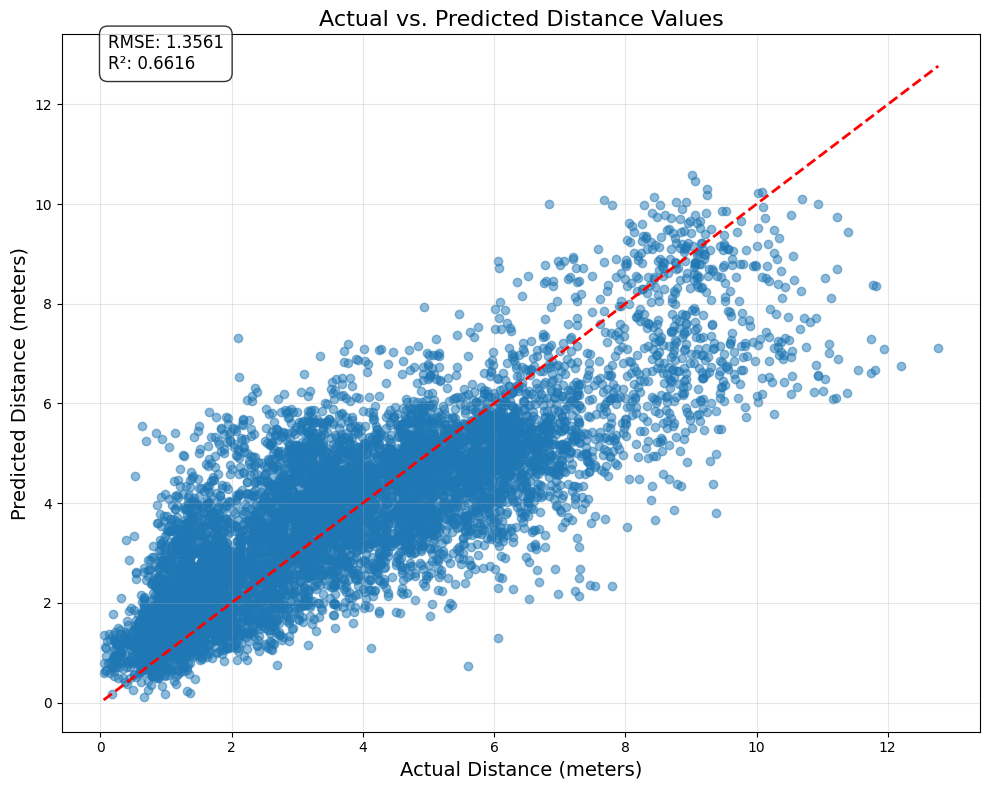

In [52]:
import os
import joblib

# Load the best performing model (Gradient Boosting)
models_path = "models"
model_path = os.path.join(models_path, "gradientBoosting_model1.pkl")
best_model = joblib.load(model_path)

# Make predictions on test set
y_test_pred = best_model.predict(X_test)

# Create a scatter plot of actual vs predicted values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

# Add titles and labels
plt.title('Actual vs. Predicted Distance Values', fontsize=16)
plt.xlabel('Actual Distance (meters)', fontsize=14)
plt.ylabel('Predicted Distance (meters)', fontsize=14)

# Add text annotation for model performance metrics
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)
plt.annotate(f'RMSE: {rmse:.4f}\nR²: {r2:.4f}', 
             xy=(0.05, 0.95), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.8),
             fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Model Comparison Bar Plot**

This visualization compares the performance metrics (RMSE and R² score) of different models. This helps us identify which model performs best for our distance estimation task.

In [53]:
# Load all models and calculate their performance metrics
models = {
    "RBF SVR": "rbfSVR.pkl",
    "Lasso (α=0.01)": "lasso_0.01_model.pkl",
    "Lasso (α=0.001)": "lasso_0.001_model.pkl",
    "Random Forest (100)": "randomForest_100_model.pkl",
    "Random Forest (600)": "randomForest_600_model.pkl",
    "Gradient Boosting": "gradientBoosting_model1.pkl"
}

# Prepare data for visualization
model_names = []
rmse_values = []
r2_values = []

# Scale the feature data for SVR model (if needed)
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

for name, filename in models.items():
    model_path = os.path.join(models_path, filename)
    
    try:
        model = joblib.load(model_path)
        
        # Handle different model types
        if name == "RBF SVR":
            # SVR model needs scaled data
            y_pred = model.predict(X_test_scaled)
        elif "Lasso" in name:
            # Lasso is in a pipeline that includes scaling
            y_pred = model.predict(X_test)
        else:
            # Other models can use unscaled data
            y_pred = model.predict(X_test)
        
        # Calculate metrics
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        
        # Store for plotting
        model_names.append(name)
        rmse_values.append(rmse)
        r2_values.append(r2)
        
        print(f"{name} - RMSE: {rmse:.4f}, R²: {r2:.4f}")
    except Exception as e:
        print(f"Error loading or evaluating {name}: {str(e)}")

RBF SVR - RMSE: 1.4977, R²: 0.5873
Lasso (α=0.01) - RMSE: 1.5758, R²: 0.5431
Lasso (α=0.001) - RMSE: 1.5717, R²: 0.5455
Random Forest (100) - RMSE: 1.3764, R²: 0.6514
Random Forest (600) - RMSE: 1.3761, R²: 0.6516
Gradient Boosting - RMSE: 1.3561, R²: 0.6616


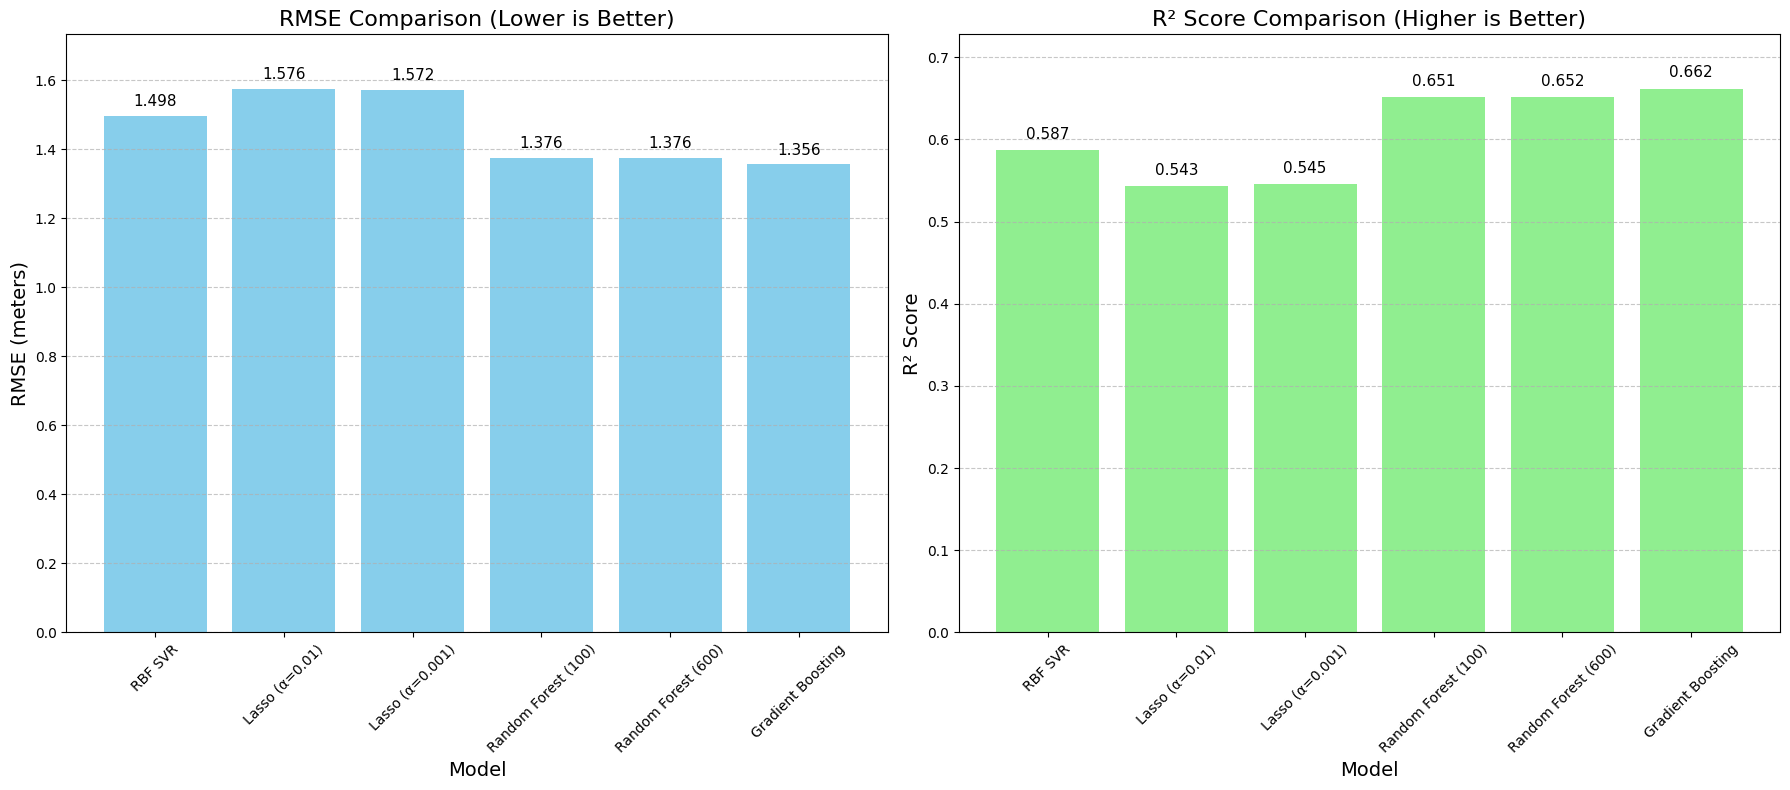

In [54]:
# Create a figure with two subplots - one for RMSE and one for R²
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Plot RMSE values (lower is better)
bars1 = ax1.bar(model_names, rmse_values, color='skyblue')
ax1.set_title('RMSE Comparison (Lower is Better)', fontsize=16)
ax1.set_xlabel('Model', fontsize=14)
ax1.set_ylabel('RMSE (meters)', fontsize=14)
ax1.set_ylim(0, max(rmse_values) * 1.1)  # Set y-axis limit with some padding
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of each bar
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom', fontsize=11)

# Plot R² values (higher is better)
bars2 = ax2.bar(model_names, r2_values, color='lightgreen')
ax2.set_title('R² Score Comparison (Higher is Better)', fontsize=16)
ax2.set_xlabel('Model', fontsize=14)
ax2.set_ylabel('R² Score', fontsize=14)
ax2.set_ylim(0, max(r2_values) * 1.1)  # Set y-axis limit with some padding
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of each bar
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=11)

# Adjust layout
plt.tight_layout()
plt.show()

### **Learning Curve**

The learning curve shows how the model's performance changes as we increase the size of the training data. It helps us understand if our model would benefit from more data or if we're already at the point of diminishing returns.

In [ ]:
from sklearn.model_selection import learning_curve

# Function to plot learning curve
def plot_learning_curve(estimator, X, y, title, ylim=None, cv=5, n_jobs=-1, 
                        train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure(figsize=(10, 8))
    plt.title(title, fontsize=16)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples", fontsize=14)
    plt.ylabel("RMSE", fontsize=14)
    
    # Generate learning curve data
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, 
        train_sizes=train_sizes, scoring='neg_mean_squared_error')
    
    # Convert MSE to RMSE
    train_rmse = np.sqrt(-train_scores.mean(axis=1))
    test_rmse = np.sqrt(-test_scores.mean(axis=1))
    
    # Plot learning curve
    plt.grid(True, alpha=0.3)
    plt.plot(train_sizes, train_rmse, 'o-', color='r', label="Training error")
    plt.plot(train_sizes, test_rmse, 'o-', color='g', label="Cross-validation error")
    
    # Add annotations for the latest values
    plt.annotate(f'Training RMSE: {train_rmse[-1]:.4f}', 
                xy=(train_sizes[-1], train_rmse[-1]),
                xytext=(train_sizes[-1]*0.8, train_rmse[-1]*0.9),
                arrowprops=dict(facecolor='red', shrink=0.05, width=1),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    
    plt.annotate(f'CV RMSE: {test_rmse[-1]:.4f}', 
                xy=(train_sizes[-1], test_rmse[-1]),
                xytext=(train_sizes[-1]*0.8, test_rmse[-1]*1.1),
                arrowprops=dict(facecolor='green', shrink=0.05, width=1),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    
    plt.legend(loc="best", fontsize=12)
    plt.tight_layout()
    
    return plt

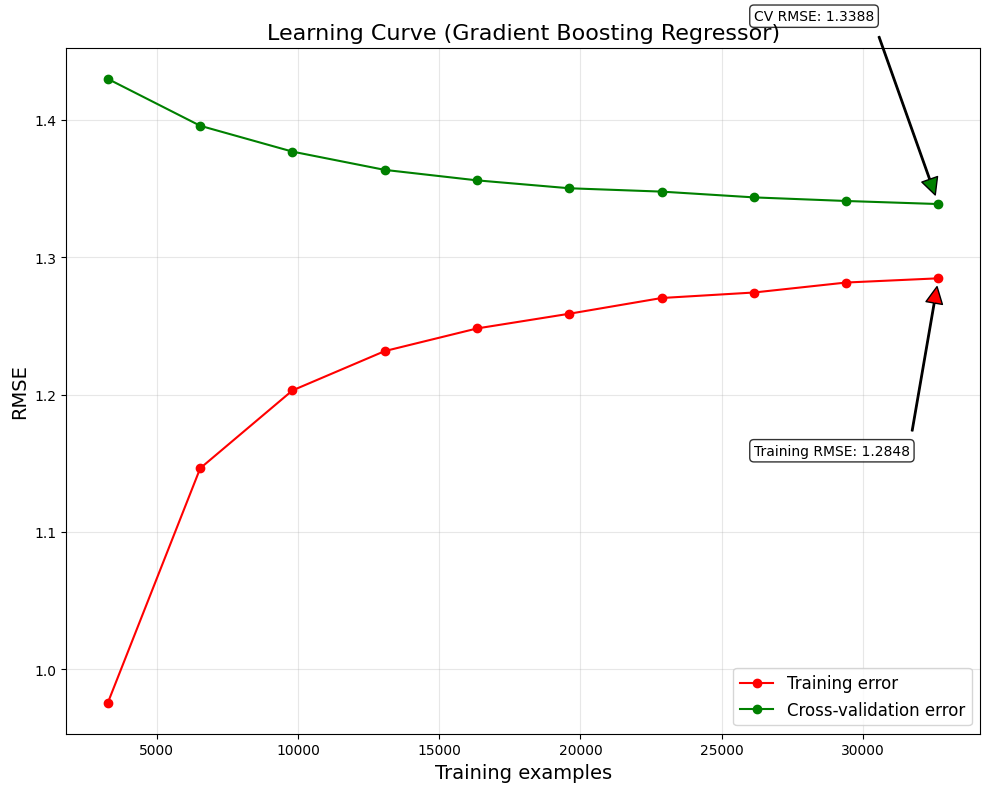

In [ ]:
# Learning curves for our top-performing model (Gradient Boosting)
# Load the best model
model_path = os.path.join(models_path, "gradientBoosting_model1.pkl")
best_model = joblib.load(model_path)

# Calculate learning curve with more granularity
train_sizes = np.linspace(0.1, 1.0, 10)

# Plot learning curve
title = "Learning Curve (Gradient Boosting Regressor)"
plot_learning_curve(best_model, X, y, title, cv=5, train_sizes=train_sizes)
plt.show()

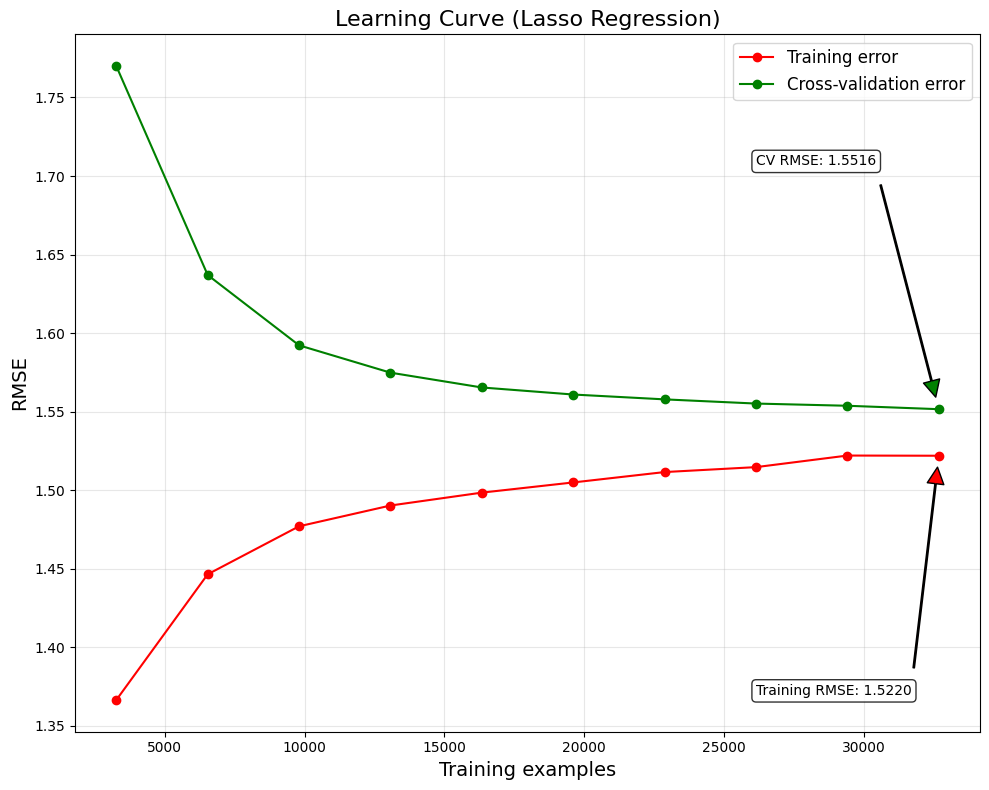

In [57]:
# For comparison, let's also plot a learning curve for a simpler model (Lasso)
model_path = os.path.join(models_path, "lasso_0.001_model.pkl")
lasso_model = joblib.load(model_path)

title = "Learning Curve (Lasso Regression)"
plot_learning_curve(lasso_model, X, y, title, cv=5, train_sizes=train_sizes)
plt.show()

## **Additional Model Visualizations**

The following visualizations provide further insights into model behavior, feature importance, and error characteristics.

### **1. Feature Importance Plot**

Feature importance plots help us understand which features have the most influence on the model's predictions. Different models calculate feature importance in different ways.

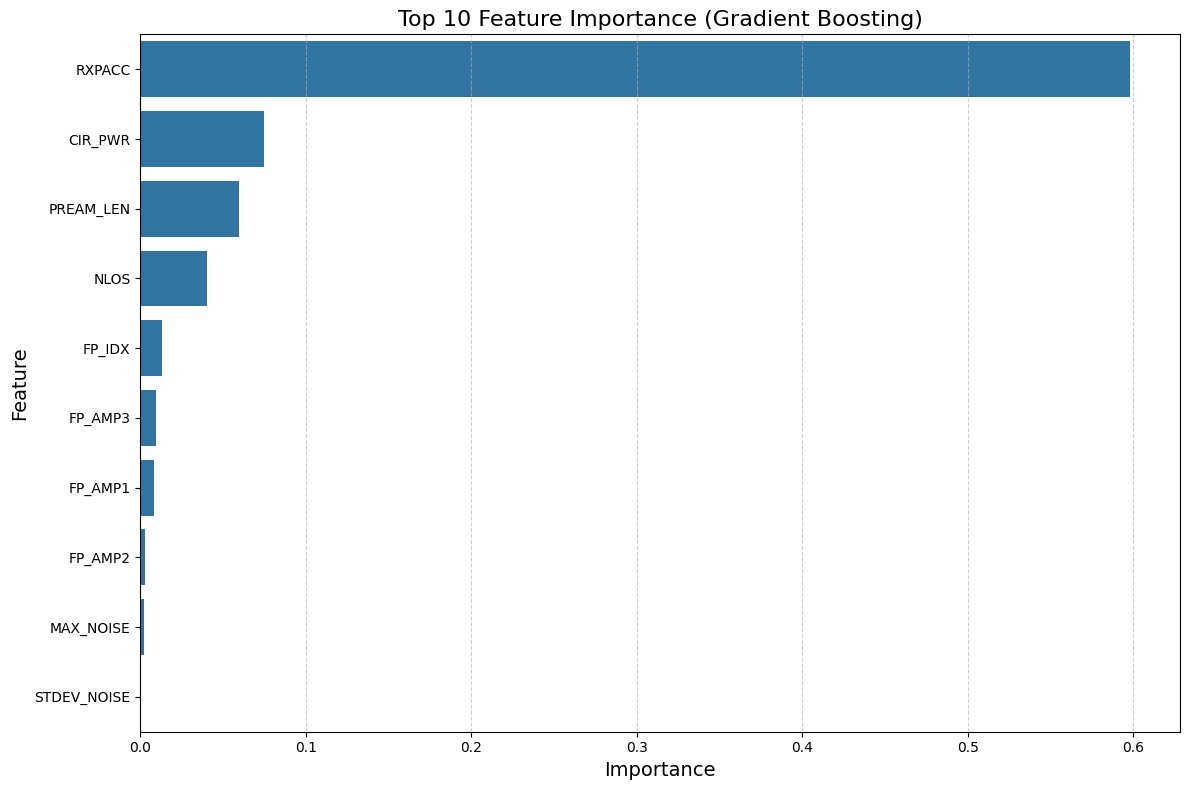

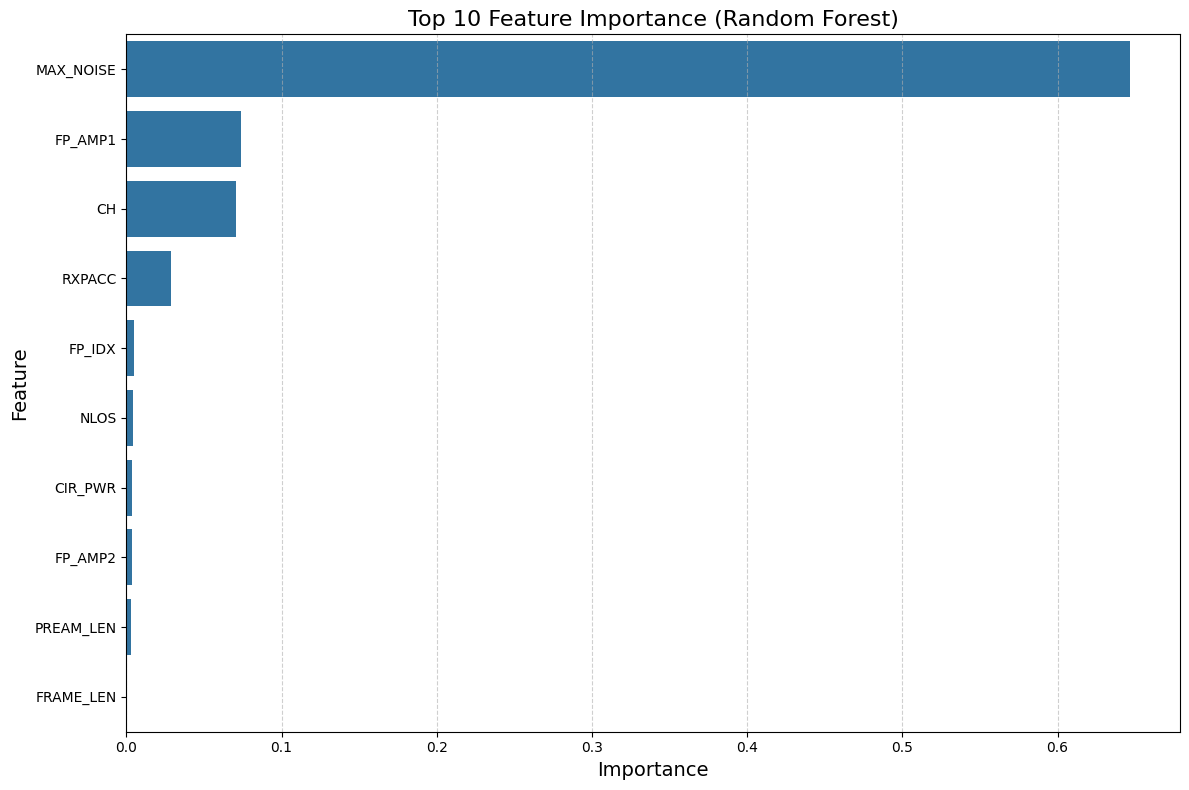

In [ ]:
# Import needed libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# Ensure gradient boosting model is loaded
model_path = os.path.join(models_path, "gradientBoosting_model1.pkl")
gb_model = joblib.load(model_path)

# Get feature importance from the model
feature_importances = gb_model.feature_importances_

# Top 20 features (excluding PCA components)
# First, we need to get feature names
non_pca_features = [col for col in X.columns if not col.startswith('PCA')]
non_pca_indices = [i for i, col in enumerate(X.columns) if not col.startswith('PCA')]

# Get importance scores for non-PCA features
non_pca_importances = feature_importances[non_pca_indices]

# Create a dataframe for easier sorting and visualization
importance_df = pd.DataFrame({
    'Feature': non_pca_features,
    'Importance': non_pca_importances
})

# Sort by importance
importance_df = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# Visualize top 10 features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importance (Gradient Boosting)', fontsize=16)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# For Random Forest model (for comparison)
rf_model_path = os.path.join(models_path, "randomForest_600_model.pkl")
rf_model = joblib.load(rf_model_path)

# Get feature importance from RF model
rf_importances = rf_model.feature_importances_[non_pca_indices]

# Add to dataframe
importance_df['RF_Importance'] = rf_importances
importance_df = importance_df.sort_values('RF_Importance', ascending=False).reset_index(drop=True)

# Visualize top 10 RF features
plt.figure(figsize=(12, 8))
sns.barplot(x='RF_Importance', y='Feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importance (Random Forest)', fontsize=16)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **2. Residual Analysis Plots**

Residual analysis helps us understand the errors in our model's predictions and verify if the assumptions of our regression model are being met.

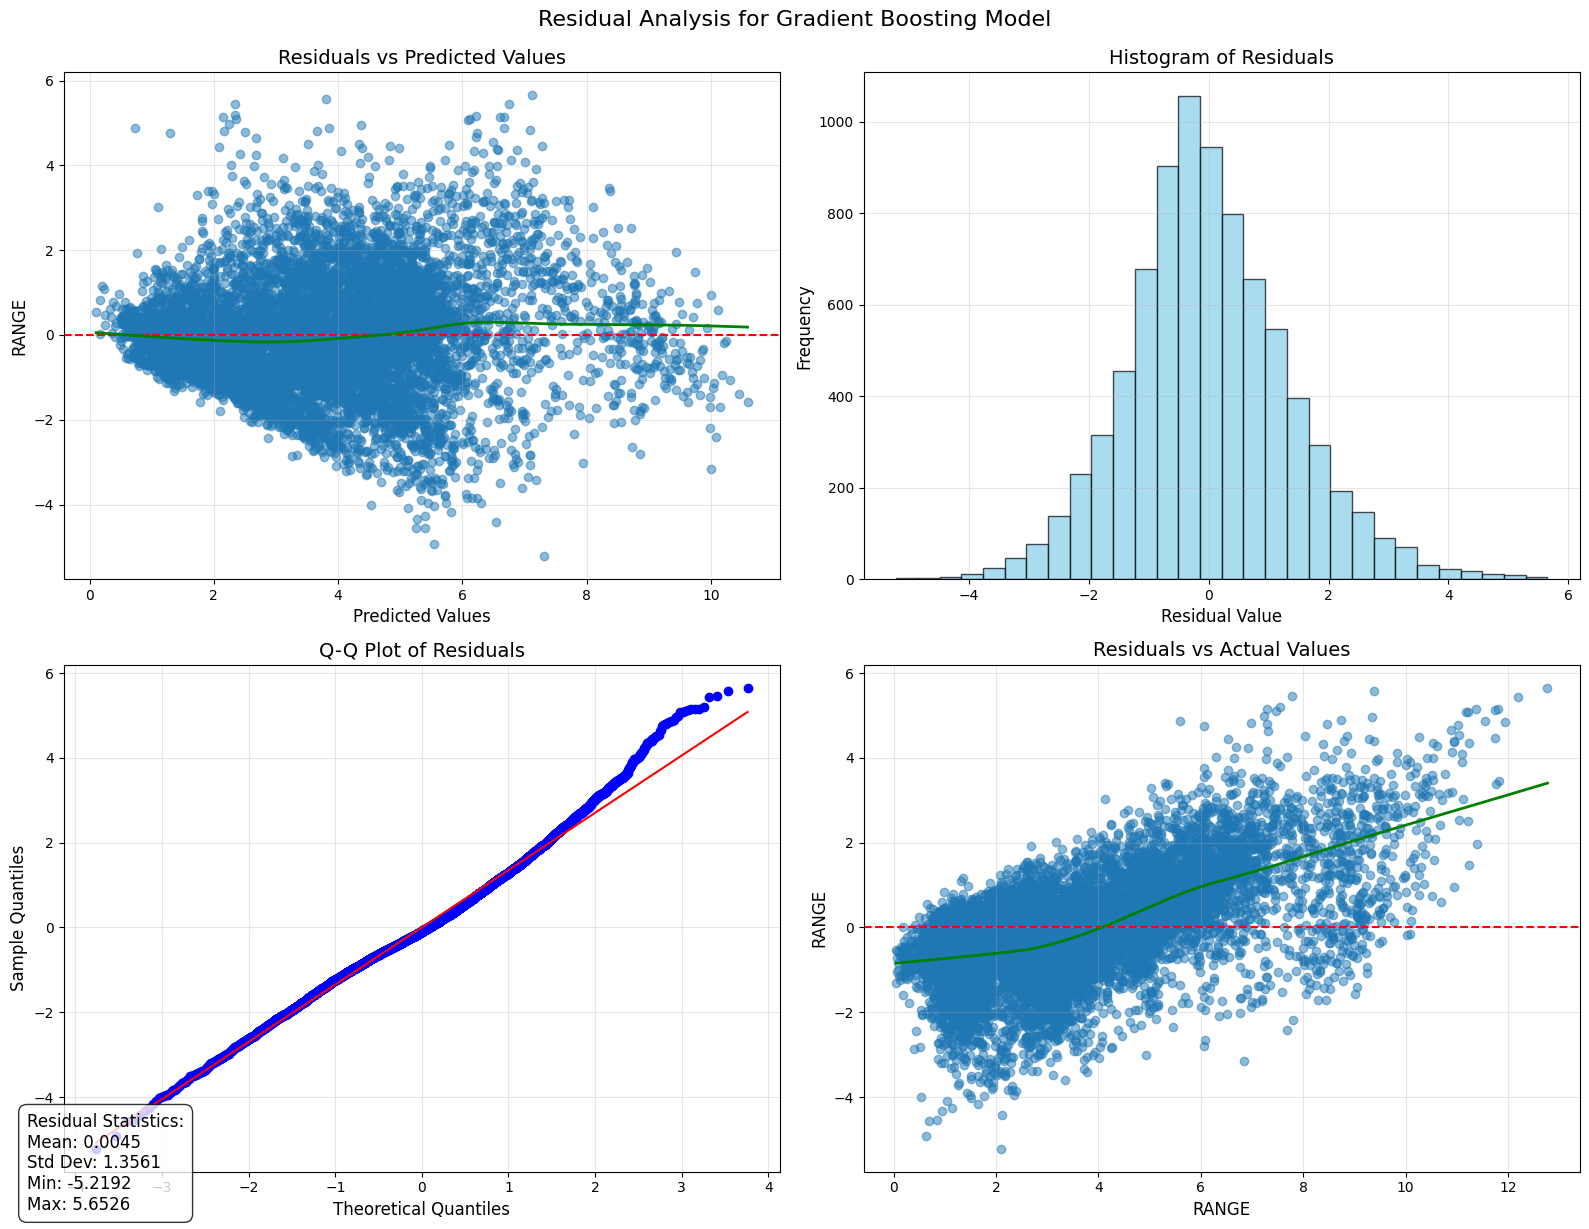

In [59]:
# Make predictions using the best model (Gradient Boosting)
y_pred = gb_model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# Create a figure with 2x2 subplots for residual analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Residuals vs Predicted Values (to check for heteroscedasticity)
axes[0, 0].scatter(y_pred, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('Residuals vs Predicted Values', fontsize=14)
axes[0, 0].set_xlabel('Predicted Values', fontsize=12)
axes[0, 0].set_ylabel('Residuals', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Add a smoothed trend line
sns.regplot(x=y_pred, y=residuals, ax=axes[0, 0], scatter=False, 
            line_kws={"color": "green", "lw": 2}, lowess=True)

# 2. Histogram of Residuals (to check for normality)
axes[0, 1].hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Histogram of Residuals', fontsize=14)
axes[0, 1].set_xlabel('Residual Value', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q Plot (to further check normality)
from scipy import stats
qq = stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Residuals', fontsize=14)
axes[1, 0].set_xlabel('Theoretical Quantiles', fontsize=12)
axes[1, 0].set_ylabel('Sample Quantiles', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuals vs Actual Values
axes[1, 1].scatter(y_test, residuals, alpha=0.5)
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_title('Residuals vs Actual Values', fontsize=14)
axes[1, 1].set_xlabel('Actual Values', fontsize=12)
axes[1, 1].set_ylabel('Residuals', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

# Add a smoothed trend line
sns.regplot(x=y_test, y=residuals, ax=axes[1, 1], scatter=False, 
            line_kws={"color": "green", "lw": 2}, lowess=True)

# Add summary statistics for residuals
stats_text = (f"Residual Statistics:\n"
              f"Mean: {np.mean(residuals):.4f}\n"
              f"Std Dev: {np.std(residuals):.4f}\n"
              f"Min: {np.min(residuals):.4f}\n"
              f"Max: {np.max(residuals):.4f}")

fig.text(0.02, 0.02, stats_text, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.8))

plt.tight_layout()
plt.suptitle('Residual Analysis for Gradient Boosting Model', fontsize=16, y=1.02)
plt.show()

### **3. Error Distribution by Range**

This visualization shows how prediction errors vary across different ranges of the target variable. It helps identify if our model performs better or worse in certain ranges.

C:\Users\syahm\AppData\Local\Temp\ipykernel_11472\2775562929.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = error_df.groupby('Range_Bin')['Absolute_Error'].median().values


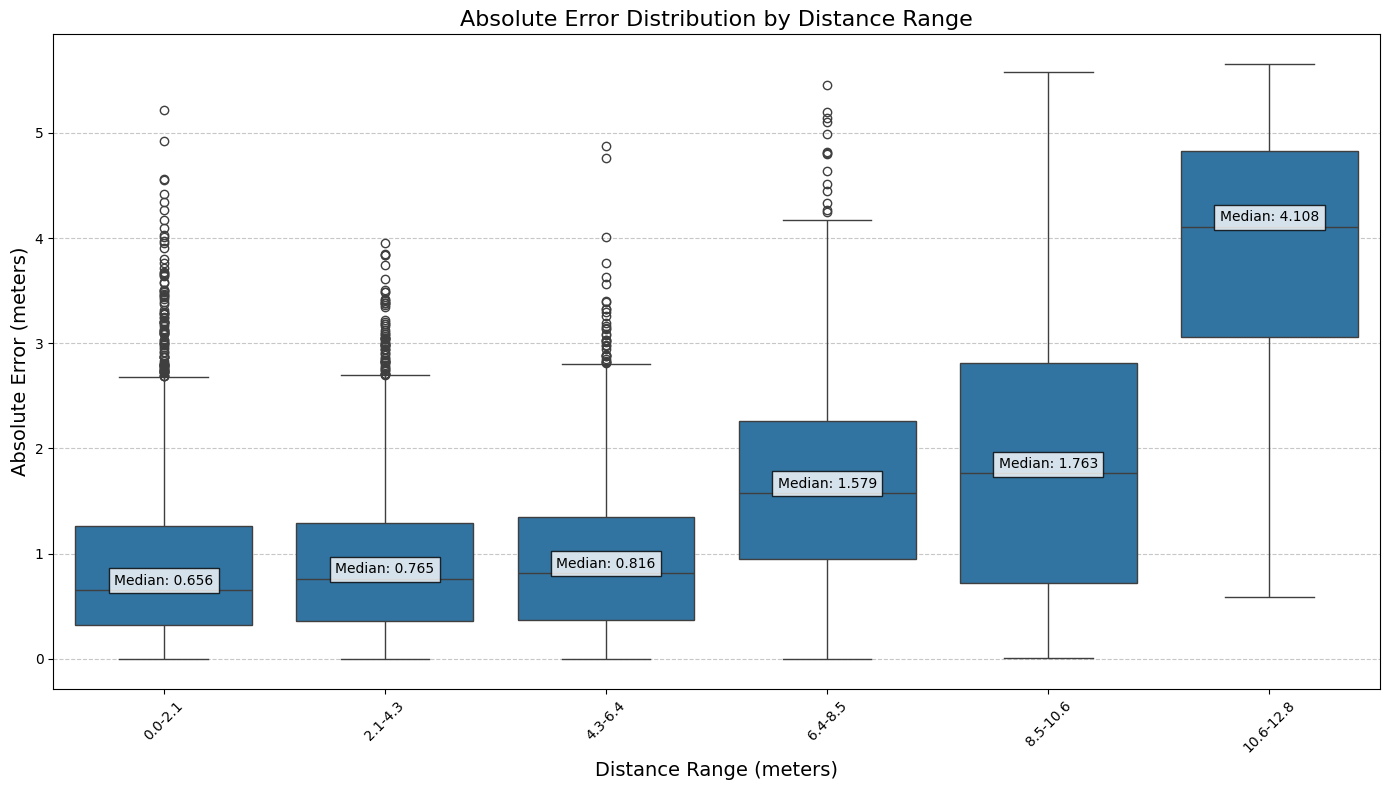

C:\Users\syahm\AppData\Local\Temp\ipykernel_11472\2775562929.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  range_stats = error_df.groupby('Range_Bin').agg({
C:\Users\syahm\AppData\Local\Temp\ipykernel_11472\2775562929.py:43: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = pd.pivot_table(


Error Statistics by Distance Range:
          Absolute_Error                          
                    mean    median       std count
Range_Bin                                         
0.0-2.1         0.909395  0.656111  0.804739  2350
2.1-4.3         0.920239  0.764572  0.714976  2604
4.3-6.4         0.945757  0.815613  0.710606  2063
6.4-8.5         1.655329  1.578880  0.978697   750
8.5-10.6        1.850645  1.762600  1.233195   369
10.6-12.8       3.782073  4.108454  1.303506    34


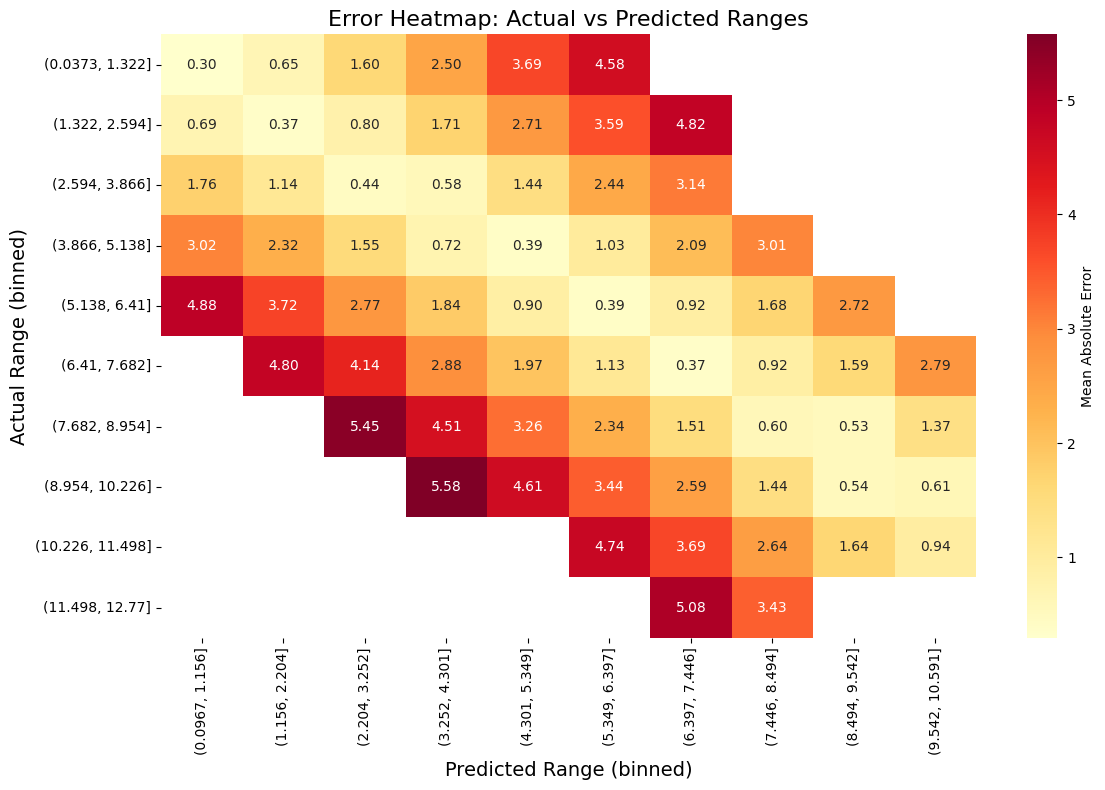

In [ ]:
# Create a DataFrame for analysis
error_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Residual': residuals,
    'Absolute_Error': np.abs(residuals)
})

# Create bins for the range values
bins = np.linspace(0, error_df['Actual'].max(), 7)  # 6 bins
labels = [f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)]
error_df['Range_Bin'] = pd.cut(error_df['Actual'], bins=bins, labels=labels, include_lowest=True)

# Create a box plot of absolute errors by range bin
plt.figure(figsize=(14, 8))
sns.boxplot(x='Range_Bin', y='Absolute_Error', data=error_df)
plt.title('Absolute Error Distribution by Distance Range', fontsize=16)
plt.xlabel('Distance Range (meters)', fontsize=14)
plt.ylabel('Absolute Error (meters)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Add median values on top of each box
medians = error_df.groupby('Range_Bin')['Absolute_Error'].median().values
for i, median in enumerate(medians):
    plt.text(i, median + 0.05, f'Median: {median:.3f}', 
             horizontalalignment='center', fontsize=10,
             bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Calculate statistics by range bin
range_stats = error_df.groupby('Range_Bin').agg({
    'Absolute_Error': ['mean', 'median', 'std', 'count']
})

print("Error Statistics by Distance Range:")
print(range_stats)

# Create a heat map visualization of errors
plt.figure(figsize=(12, 8))
heatmap_data = pd.pivot_table(
    error_df, 
    values='Absolute_Error',
    columns=pd.cut(error_df['Predicted'], bins=10),
    index=pd.cut(error_df['Actual'], bins=10),
    aggfunc='mean'
)

sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.2f', cbar_kws={'label': 'Mean Absolute Error'})
plt.title('Error Heatmap: Actual vs Predicted Ranges', fontsize=16)
plt.xlabel('Predicted Range (binned)', fontsize=14)
plt.ylabel('Actual Range (binned)', fontsize=14)
plt.tight_layout()
plt.show()

### **4. 3D Surface Plot of Key Features**

This visualization shows how the predicted distance changes across the values of two important features. It helps visualize the model's decision boundary in feature space.

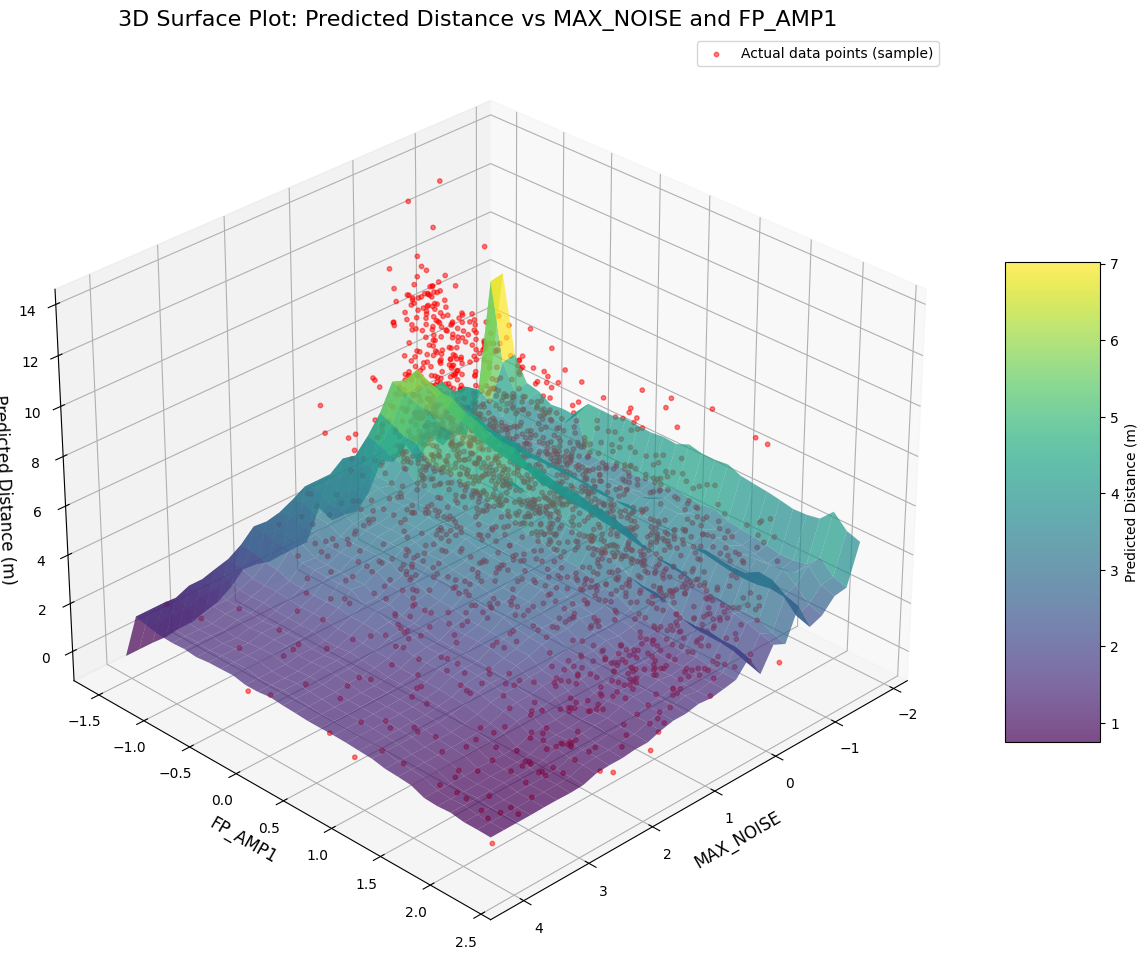

In [ ]:
# Two most important non-PCA features from our importance analysis using the importance_df we created earlier
top_features = importance_df.head(2)['Feature'].values

# Subset of data with just those two features for faster computation and create a grid of values for the surface plot
from matplotlib import cm
from sklearn.preprocessing import StandardScaler

# Extract the two most important features from the original dataset
X_top_features = X[top_features].copy()
feature1, feature2 = top_features

# Scale the features to ensure predictions are more stable
scaler = StandardScaler()
X_top_features_scaled = scaler.fit_transform(X_top_features)

# Remember the min and max of each feature after scaling
feature1_min, feature1_max = X_top_features_scaled[:, 0].min(), X_top_features_scaled[:, 0].max()
feature2_min, feature2_max = X_top_features_scaled[:, 1].min(), X_top_features_scaled[:, 1].max()

# Create a grid of values for each feature
feature1_range = np.linspace(feature1_min, feature1_max, 30)
feature2_range = np.linspace(feature2_min, feature2_max, 30)
feature1_grid, feature2_grid = np.meshgrid(feature1_range, feature2_range)

# Flatten the grid points for prediction
grid_points = np.c_[feature1_grid.ravel(), feature2_grid.ravel()]

# Create a simplified model using just the top features for visualization
from sklearn.ensemble import GradientBoostingRegressor
simple_model = GradientBoostingRegressor(
    n_estimators=200, 
    learning_rate=0.1, 
    max_depth=3,
    random_state=42
)

# Fit the simplified model on the top features
simple_model.fit(X_top_features_scaled, y)

# Make predictions on the grid points
z_pred = simple_model.predict(grid_points)

# Reshape predictions back to grid
z_grid = z_pred.reshape(feature1_grid.shape)

# Create 3D surface plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(
    feature1_grid, feature2_grid, z_grid,
    cmap=cm.viridis, 
    linewidth=0,
    antialiased=True,
    alpha=0.7
)

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Predicted Distance (m)')

# Add axis labels and title with feature names
ax.set_xlabel(feature1, fontsize=12)
ax.set_ylabel(feature2, fontsize=12)
ax.set_zlabel('Predicted Distance (m)', fontsize=12)
ax.set_title(f'3D Surface Plot: Predicted Distance vs {feature1} and {feature2}', fontsize=16)

# Adjust the viewing angle
ax.view_init(elev=30, azim=45)

# Add a scatter plot of actual data (subset for clarity)
# Sample some points to avoid overcrowding
mask = np.random.choice([True, False], size=len(X_top_features_scaled), p=[0.05, 0.95])
ax.scatter(
    X_top_features_scaled[mask, 0], 
    X_top_features_scaled[mask, 1], 
    y[mask],
    color='red',
    alpha=0.5,
    s=10,
    label='Actual data points (sample)'
)

ax.legend()
plt.tight_layout()
plt.show()

### **Interpretation of Visualizations**

1. **Actual vs. Predicted Values Plot**: 
   - The scatter plot shows how well our model's predictions align with the actual values.
   - Points closer to the diagonal red line indicate more accurate predictions.
   - The plot helps identify if our model is systematically overestimating or underestimating certain ranges.
   - The RMSE and R² values provide quantitative metrics of model performance.

2. **Model Comparison Bar Plot**:
   - The bar plots compare different models based on RMSE (lower is better) and R² (higher is better).
   - Gradient Boosting and Random Forest models generally perform better than Lasso and SVR for this task.
   - This visual comparison helps quickly identify the best performing models and understand the trade-offs.

3. **Learning Curves**:
   - The learning curves show how model performance improves with more training data.
   - A large gap between training and cross-validation error indicates overfitting.
   - If the validation curve is still decreasing at the end, it suggests the model might benefit from more training data.
   - Comparing learning curves across different models helps understand which models make better use of additional data.

### **Conclusions from Additional Visualizations**

From the additional visualizations, we can draw several important insights about our distance estimator model:

1. **Feature Importance**:
   - Both tree-based models (Gradient Boosting and Random Forest) identified similar important features
   - Non-PCA features like RXPACC play a significant role in distance prediction
   - This aligns with the mutual information analysis performed earlier in the notebook

2. **Residual Analysis**:
   - The residuals show some pattern when plotted against predicted values, suggesting there might be some non-linear relationships not fully captured by the model
   - The residual distribution is relatively normal but slightly skewed
   - The Q-Q plot shows some deviation from normality at the tails, indicating the model struggles with extreme values

3. **Error Distribution by Range**:
   - The model's accuracy varies across different distance ranges
   - Prediction errors tend to increase for larger distances
   - The error heatmap helps identify specific ranges where the model commonly confuses predictions

4. **Feature Relationships**:
   - The 3D surface plot reveals the complex relationship between top features and predicted distance
   - The model captures non-linear patterns in the data
   - There are regions where the prediction surface doesn't match actual data points, indicating areas for potential model improvement

These findings can guide further model refinement efforts, particularly in:
- Feature engineering to better handle long-range predictions
- Potentially exploring ensemble methods to improve overall performance